In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
file_paths = sorted(glob.glob("csv_results/gender_sample_fraction_large_30*.csv"))
all_dfs = []

for path in file_paths:
    df = pd.read_csv(path)
    df["sample_fraction"] = float(path.split("_")[-1].replace(".csv", ""))
    all_dfs.append(df)

# Объединяем в один DataFrame
df_all = pd.concat(all_dfs, ignore_index=True)

In [3]:
len(df_all)

6450

In [4]:
print(df_all)

      Unnamed: 0  batch_size  learning_rate  split_count  cnt_min  cnt_max  \
0              0          16          0.001            3       10      100   
1              1          16          0.001            3       10      100   
2              2          16          0.001            3       10      100   
3              3          16          0.001            3       10      100   
4              4          16          0.001            3       10      100   
...          ...         ...            ...          ...      ...      ...   
6445        1285          64          0.001            3       10      100   
6446        1286          64          0.001            3       10      100   
6447        1287          64          0.001            3       10      100   
6448        1288          64          0.001            3       10      100   
6449        1289          64          0.001            3       10      100   

      embedding_dim  category_embedding_dim  hidden_size  mcc_c

In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()

scaled = scaler.fit_transform(df_all[["metric_ripser_sum_H0", "metric_ripser_sum_H1"]])
weighted_sum = np.mean(scaled, axis=1)
df_all['ripser_weighted'] = weighted_sum

In [ ]:
#combinations
metric_columns = [col for col in df_all.columns if col.startswith("metric_")] \
+ ['ripser_weighted', 'recall_topk']
all_metric_columns = []
for metric1 in metric_columns:
    for metric2 in metric_columns:
        scaler = MinMaxScaler()
        scaled = scaler.fit_transform(df_all[[metric1, metric2]])
        weighted_sum = np.mean(scaled, axis=1)
        all_metric_columns.append(metric1 + "_" + metric2 + '_weighted')
        all_metric_columns.append(metric1 + "_" + metric2 + '_prod')
        df_all[metric1 + "_" + metric2 + '_weighted'] = weighted_sum
        df_all[metric1 + "_" + metric2 + '_prod'] = scaled[:,0] * scaled[:,1]

all_metric_columns += metric_columns

In [7]:
df_all = df_all.set_index('checkpoint')

In [8]:
corr_records = []

# Вычисляем корреляцию с accuracy для каждой метрики при каждом sample_fraction
for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))

        if sub[metric].nunique() > 1:  # нужно хотя бы 2 уникальных значения для корреляции
            corr = sub[metric].corr(sub['roc_auc'])
            corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": sign * corr
            })

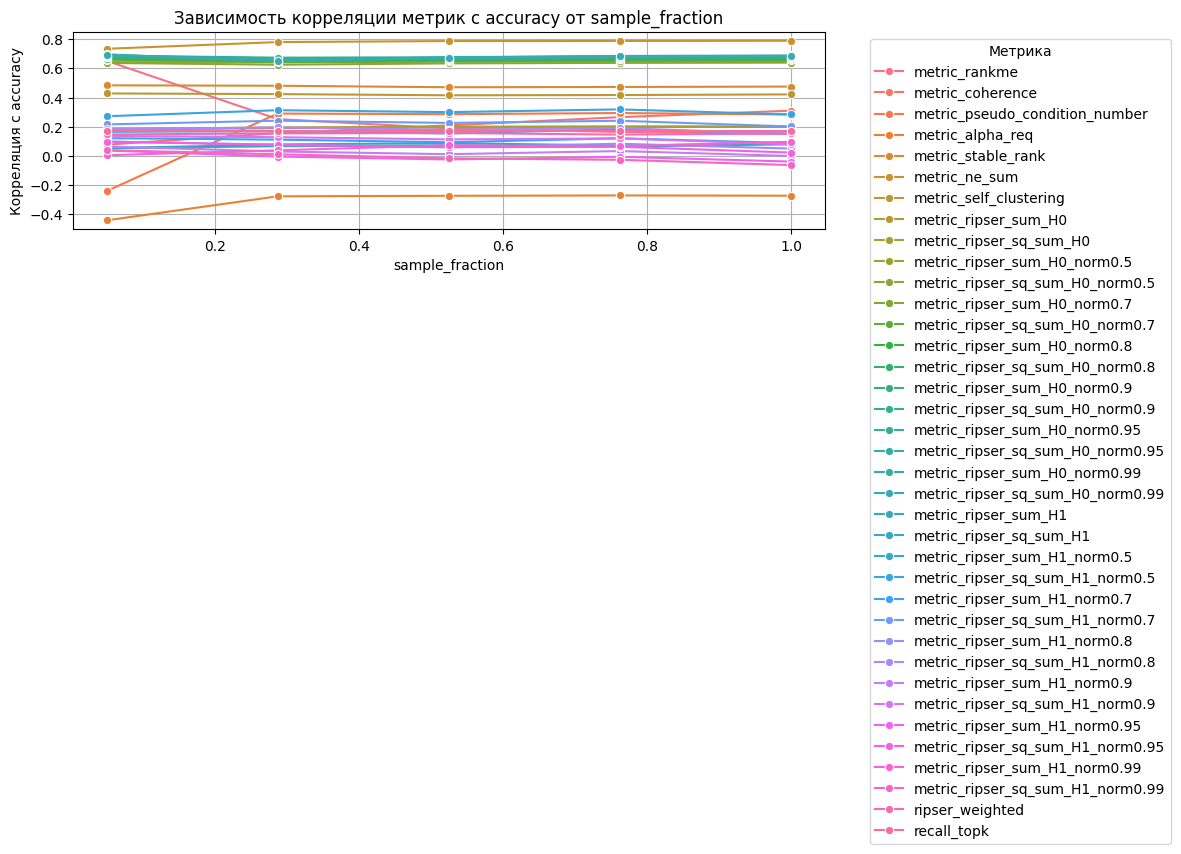

In [9]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [10]:
print(corr_df)

     sample_fraction                            metric  correlation
0               0.05                     metric_rankme     0.651430
1               0.05                  metric_coherence     0.076665
2               0.05    metric_pseudo_condition_number    -0.240854
3               0.05                  metric_alpha_req    -0.442540
4               0.05                metric_stable_rank     0.483882
..               ...                               ...          ...
180             1.00  metric_ripser_sq_sum_H1_norm0.95     0.022511
181             1.00     metric_ripser_sum_H1_norm0.99     0.096507
182             1.00  metric_ripser_sq_sum_H1_norm0.99    -0.063410
183             1.00                   ripser_weighted     0.153382
184             1.00                       recall_topk     0.167791

[185 rows x 3 columns]


In [11]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.776370
metric_ripser_sum_H0_norm0.95       0.680888
metric_ripser_sum_H0_norm0.99       0.679713
metric_ripser_sq_sum_H0_norm0.99    0.677349
metric_ripser_sq_sum_H0_norm0.95    0.677268
metric_ripser_sum_H0_norm0.9        0.675219
metric_ripser_sq_sum_H0_norm0.9     0.670639
metric_ripser_sum_H0_norm0.8        0.666851
metric_ripser_sq_sum_H0_norm0.8     0.660791
metric_ripser_sum_H0_norm0.7        0.660171
metric_ripser_sq_sum_H0_norm0.7     0.652745
metric_ripser_sum_H0_norm0.5        0.645734
metric_ripser_sq_sum_H0_norm0.5     0.635044
metric_stable_rank                  0.476761
metric_self_clustering              0.421296
metric_ripser_sq_sum_H1_norm0.5     0.297460
metric_rankme                       0.281163
metric_ripser_sq_sum_H1_norm0.7     0.225006
metric_coherence                    0.203341
metric_ripser_sum_H0                0.196014
metric_ripser_sq_sum_H0             0.192540
metric_pseudo_condition_number      0.182469
met

In [12]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.789824
metric_ripser_sum_H0_norm0.99       0.688895
metric_ripser_sq_sum_H0_norm0.99    0.685786
metric_ripser_sum_H0_norm0.95       0.684186
metric_ripser_sq_sum_H0_norm0.95    0.680107
metric_ripser_sum_H0_norm0.9        0.678338
metric_ripser_sq_sum_H0_norm0.9     0.673506
metric_ripser_sum_H0_norm0.8        0.669669
metric_ripser_sq_sum_H0_norm0.8     0.663658
metric_ripser_sum_H0_norm0.7        0.662581
metric_ripser_sq_sum_H0_norm0.7     0.655479
metric_ripser_sum_H0_norm0.5        0.649135
metric_ripser_sq_sum_H0_norm0.5     0.639560
metric_stable_rank                  0.475364
metric_self_clustering              0.421644
metric_coherence                    0.309810
metric_ripser_sq_sum_H1_norm0.5     0.283699
metric_pseudo_condition_number      0.283628
metric_ripser_sq_sum_H1_norm0.7     0.201597
metric_ripser_sum_H0                0.201540
metric_ripser_sq_sum_H0             0.198418
recall_topk                         0.167791
rip

In [13]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ne_sum                       0.757815
metric_ripser_sum_H0_norm0.95       0.680887
metric_ripser_sq_sum_H0_norm0.95    0.677920
metric_ripser_sum_H0_norm0.9        0.674674
metric_ripser_sum_H0_norm0.99       0.673644
metric_ripser_sq_sum_H0_norm0.99    0.671949
metric_ripser_sq_sum_H0_norm0.9     0.670614
metric_ripser_sum_H0_norm0.8        0.665962
metric_ripser_sq_sum_H0_norm0.8     0.660221
metric_ripser_sum_H0_norm0.7        0.659397
metric_ripser_sq_sum_H0_norm0.7     0.652108
metric_ripser_sum_H0_norm0.5        0.642728
metric_ripser_sq_sum_H0_norm0.5     0.631543
metric_stable_rank                  0.482512
metric_rankme                       0.451732
metric_self_clustering              0.425954
metric_ripser_sq_sum_H1_norm0.5     0.292447
metric_ripser_sq_sum_H1_norm0.7     0.228459
metric_ripser_sq_sum_H1_norm0.8     0.188961
metric_ripser_sum_H0                0.188383
metric_ripser_sq_sum_H0             0.184945
recall_topk                         0.167791
met

# Overall Spearmann Corr

In [14]:
from scipy.stats import spearmanr


spear_corr_records = []

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        if sub[metric].nunique() > 1 and sub['accuracy'].nunique() > 1:
            corr, _ = spearmanr(sub[metric], sub['roc_auc'])
            spear_corr_records.append({
                "sample_fraction": frac,
                "metric": metric,
                "correlation": sign * corr
            })
            


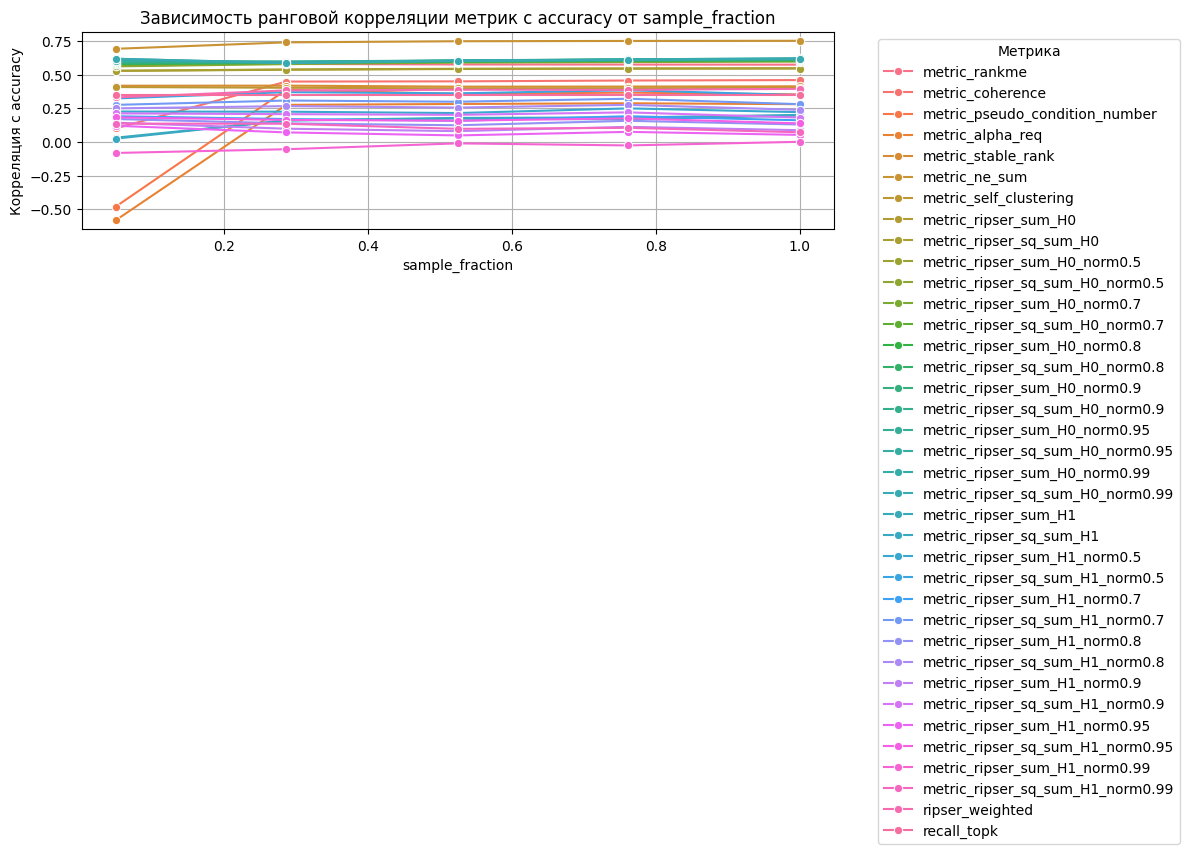

In [15]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [16]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.7527877033337171,
 'metric_ripser_sum_H0_norm0.99': 0.6223052748346759,
 'metric_ripser_sum_H0_norm0.95': 0.6204622719050549,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6194315028344373,
 'metric_ripser_sq_sum_H0_norm0.95': 0.61730178357104,
 'metric_ripser_sum_H0_norm0.9': 0.616328571611981,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6128823434410614,
 'metric_ripser_sum_H0_norm0.8': 0.6109843564394296,
 'metric_ripser_sum_H0_norm0.7': 0.6078419071152231,
 'metric_ripser_sq_sum_H0_norm0.8': 0.607234976348941,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6035192325809143,
 'metric_ripser_sum_H0_norm0.5': 0.6031181585486618,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5976552866288494,
 'metric_rankme': 0.5750304044789676,
 'metric_ripser_sum_H0': 0.5483556239379838,
 'metric_ripser_sq_sum_H0': 0.5463448156034996,
 'metric_coherence': 0.46024154959947977,
 'metric_stable_rank': 0.4139165832944819,
 'metric_self_clustering': 0.4016065810746243,
 'ripser_weighted': 0.39507442433520124,
 'me

In [17]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.7375726226958403,
 'metric_ripser_sum_H0_norm0.99': 0.6098339468038647,
 'metric_ripser_sum_H0_norm0.95': 0.6085455044355665,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6078831481537299,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6067326508556095,
 'metric_ripser_sum_H0_norm0.9': 0.6042633963709175,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6018933316918168,
 'metric_ripser_sum_H0_norm0.8': 0.5990650937918278,
 'metric_ripser_sum_H0_norm0.7': 0.5960746078121747,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5959181250567654,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5924022856540447,
 'metric_ripser_sum_H0_norm0.5': 0.5899006008956456,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5847920662947578,
 'metric_rankme': 0.5823167938457865,
 'metric_ripser_sum_H0': 0.5417119815190345,
 'metric_ripser_sq_sum_H0': 0.5399524847160393,
 'metric_stable_rank': 0.41486788478228265,
 'metric_self_clustering': 0.4021662580402333,
 'metric_coherence': 0.38348830557618363,
 'ripser_weighted': 0.37707927536386987,

In [18]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.7170290265015158,
 'metric_ripser_sum_H0_norm0.99': 0.6037554083708339,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6026535613397195,
 'metric_ripser_sum_H0_norm0.95': 0.6000754199265562,
 'metric_ripser_sq_sum_H0_norm0.95': 0.5995077741030432,
 'metric_ripser_sum_H0_norm0.9': 0.5938333327538001,
 'metric_ripser_sq_sum_H0_norm0.9': 0.5923551508327738,
 'metric_rankme': 0.5922014580558853,
 'metric_ripser_sum_H0_norm0.8': 0.5874573002440451,
 'metric_ripser_sq_sum_H0_norm0.8': 0.5850424129272641,
 'metric_ripser_sum_H0_norm0.7': 0.5845073259145999,
 'metric_ripser_sq_sum_H0_norm0.7': 0.5815119087911788,
 'metric_ripser_sum_H0_norm0.5': 0.5754598175742196,
 'metric_ripser_sq_sum_H0_norm0.5': 0.5707321029880452,
 'metric_ripser_sum_H0': 0.5343548403419707,
 'metric_ripser_sq_sum_H0': 0.5330970670828865,
 'metric_stable_rank': 0.41857784851592794,
 'metric_self_clustering': 0.405732833107509,
 'ripser_weighted': 0.3571799756843173,
 'recall_topk': 0.3515304135512426,
 'metri

# Correlation for best checkpoint choice

In [19]:
from scipy.stats import spearmanr


spear_corr_records = []
df_all['checkpoint'] = df_all.index.values
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr, _ = spearmanr(check_data[metric], check_data['roc_auc'])
                spear_corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
            


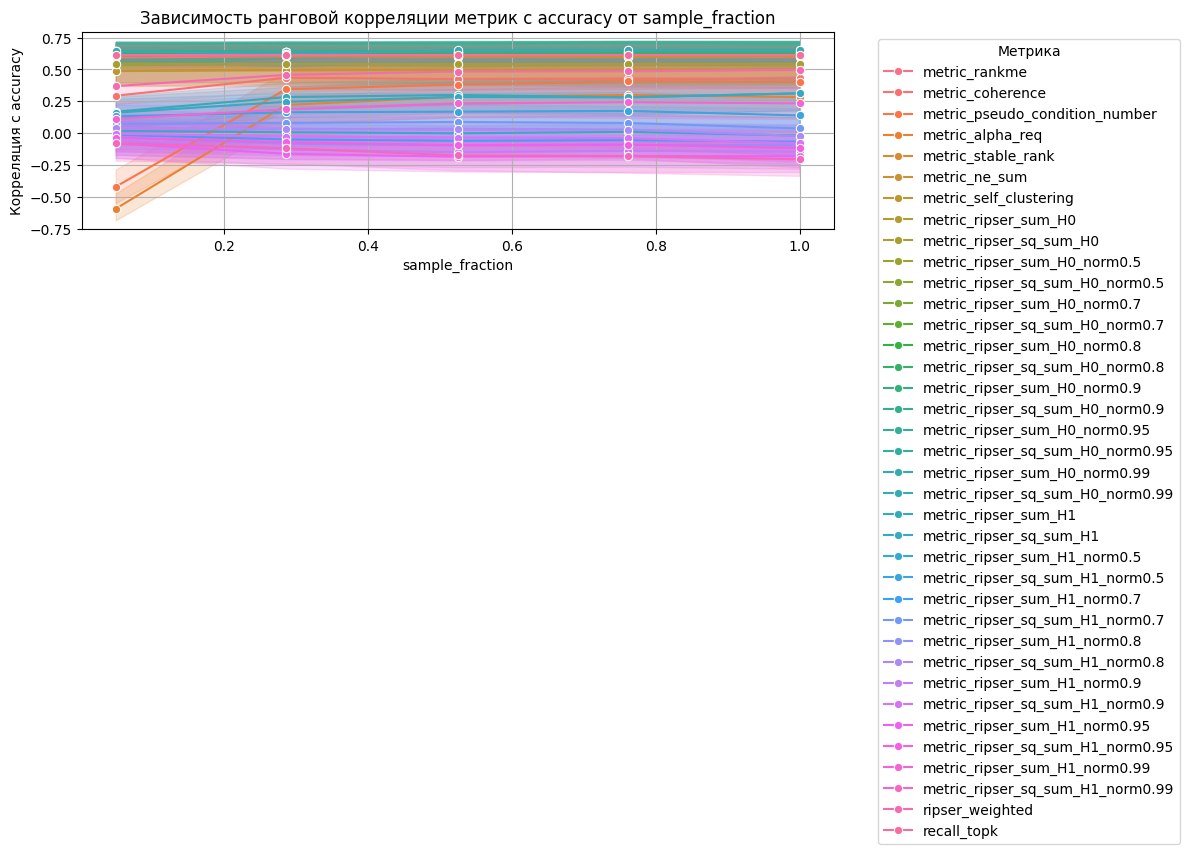

In [20]:
spear_corr_df = pd.DataFrame(spear_corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=spear_corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [21]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sq_sum_H0_norm0.99': 0.6500669199140731,
 'metric_ripser_sum_H0_norm0.99': 0.6496838826654516,
 'metric_ripser_sum_H0_norm0.95': 0.6449501853643951,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6440540860747919,
 'metric_ripser_sum_H0_norm0.9': 0.6421138269024252,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6415576884506674,
 'metric_ripser_sum_H0_norm0.8': 0.6399140469252843,
 'metric_ripser_sum_H0_norm0.7': 0.6342595603959449,
 'metric_ripser_sq_sum_H0_norm0.8': 0.633001172610051,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6275150798353094,
 'metric_ripser_sum_H0_norm0.5': 0.6175577259754601,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6172671597719305,
 'recall_topk': 0.6152269455821133,
 'metric_ne_sum': 0.602649524897968,
 'metric_rankme': 0.5982548891112547,
 'metric_ripser_sum_H0': 0.5440565735065103,
 'metric_ripser_sq_sum_H0': 0.5434632557362932,
 'metric_stable_rank': 0.5006791522100834,
 'ripser_weighted': 0.49808504401734033,
 'metric_self_clustering': 0.4975555465013753,
 'metric

In [22]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.95': 0.6428464136331516,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6427202839775586,
 'metric_ripser_sum_H0_norm0.99': 0.6425317179869401,
 'metric_ripser_sq_sum_H0_norm0.95': 0.642044776405039,
 'metric_ripser_sum_H0_norm0.9': 0.6406078582784963,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6385185003433623,
 'metric_ripser_sum_H0_norm0.8': 0.6355369730571954,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6310642573990053,
 'metric_ripser_sum_H0_norm0.7': 0.6288489473513404,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6254563742718529,
 'metric_ripser_sum_H0_norm0.5': 0.6168123027221684,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6153503487755165,
 'recall_topk': 0.6152269455821134,
 'metric_ne_sum': 0.6048739378799646,
 'metric_rankme': 0.598857392164167,
 'metric_ripser_sq_sum_H0': 0.5433127622281603,
 'metric_ripser_sum_H0': 0.543303718784519,
 'metric_stable_rank': 0.4975770371611221,
 'metric_self_clustering': 0.4933724018707662,
 'ripser_weighted': 0.4592684735750628,
 'metric_c

In [23]:
mean_corr = spear_corr_df[spear_corr_df['sample_fraction'] < 0.5].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.95': 0.6413706412368186,
 'metric_ripser_sq_sum_H0_norm0.95': 0.6404664412160206,
 'metric_ripser_sum_H0_norm0.9': 0.638219154577555,
 'metric_ripser_sq_sum_H0_norm0.9': 0.6364264377831752,
 'metric_ripser_sq_sum_H0_norm0.99': 0.6328624166163707,
 'metric_ripser_sum_H0_norm0.99': 0.6328270061107243,
 'metric_ripser_sum_H0_norm0.8': 0.6313569504967045,
 'metric_ripser_sq_sum_H0_norm0.8': 0.6282972155535097,
 'metric_ripser_sum_H0_norm0.7': 0.6260662875752045,
 'metric_ripser_sq_sum_H0_norm0.7': 0.6247687514480913,
 'metric_ripser_sum_H0_norm0.5': 0.6156876064071433,
 'recall_topk': 0.6152269455821133,
 'metric_ripser_sq_sum_H0_norm0.5': 0.6141995560141752,
 'metric_ne_sum': 0.6100549178712131,
 'metric_rankme': 0.5984230589088614,
 'metric_ripser_sq_sum_H0': 0.5434566132162798,
 'metric_ripser_sum_H0': 0.5431509973189618,
 'metric_stable_rank': 0.49570127491262156,
 'metric_self_clustering': 0.49047083365536753,
 'metric_coherence': 0.43098531045834515,
 'ri

# Linear correlation of epoch choice

In [24]:

corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):        
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                corr = check_data[metric].corr(check_data['roc_auc'])
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "correlation": sign * corr
                })
     

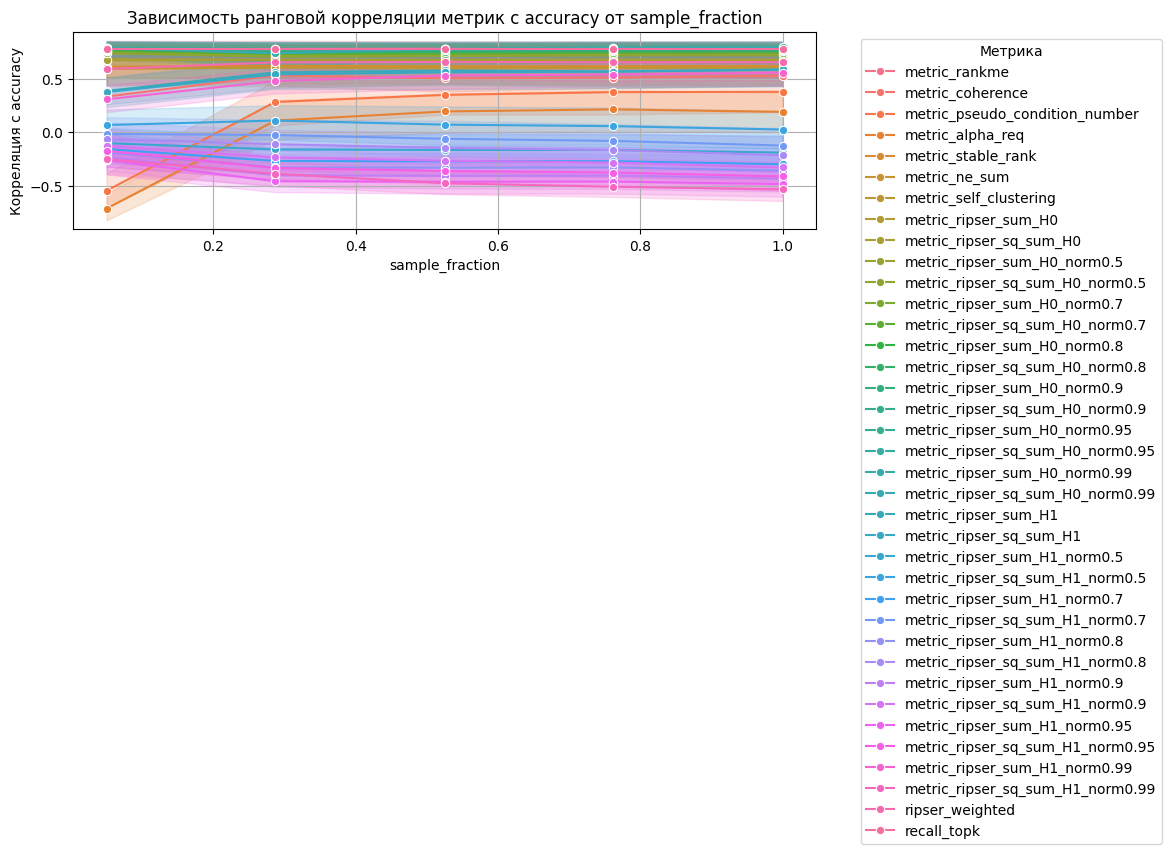

In [25]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="correlation", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [26]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ripser_sum_H0_norm0.99       0.792933
metric_ripser_sq_sum_H0_norm0.99    0.792744
metric_ripser_sum_H0_norm0.95       0.782797
metric_ripser_sq_sum_H0_norm0.95    0.781463
recall_topk                         0.779455
metric_ripser_sum_H0_norm0.9        0.774805
metric_ripser_sq_sum_H0_norm0.9     0.772398
metric_ripser_sum_H0_norm0.8        0.762093
metric_ripser_sq_sum_H0_norm0.8     0.757474
metric_ne_sum                       0.756413
metric_ripser_sum_H0_norm0.7        0.750782
metric_ripser_sq_sum_H0_norm0.7     0.743979
metric_rankme                       0.739781
metric_ripser_sum_H0_norm0.5        0.727590
metric_ripser_sq_sum_H0_norm0.5     0.717657
metric_ripser_sum_H0                0.676706
metric_ripser_sq_sum_H0             0.676552
ripser_weighted                     0.656132
metric_stable_rank                  0.618789
metric_self_clustering              0.602423
metric_ripser_sq_sum_H1             0.586892
metric_ripser_sum_H1                0.584421
met

In [27]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
mean_corr

metric
metric_ripser_sum_H0_norm0.95       0.781943
metric_ripser_sq_sum_H0_norm0.95    0.781072
recall_topk                         0.779455
metric_ripser_sum_H0_norm0.9        0.775626
metric_ripser_sq_sum_H0_norm0.9     0.772848
metric_ripser_sum_H0_norm0.8        0.764276
metric_ripser_sum_H0_norm0.99       0.763446
metric_ripser_sq_sum_H0_norm0.99    0.763283
metric_ripser_sq_sum_H0_norm0.8     0.758719
metric_ne_sum                       0.754274
metric_rankme                       0.752587
metric_ripser_sum_H0_norm0.7        0.752106
metric_ripser_sq_sum_H0_norm0.7     0.744804
metric_ripser_sum_H0_norm0.5        0.730334
metric_ripser_sq_sum_H0_norm0.5     0.721234
metric_ripser_sq_sum_H0             0.677401
metric_ripser_sum_H0                0.677340
ripser_weighted                     0.621661
metric_stable_rank                  0.615556
metric_self_clustering              0.597950
metric_coherence                    0.523680
metric_ripser_sum_H1                0.472660
met

# Score of best epoch

In [28]:
corr_records = []
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for metric in metric_columns:
        sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
            sub['roc_auc'], method='spearman'))
        for check, check_data in sub.groupby('runs'):
            if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                pick = check_data['roc_auc'].values[
                    np.argmax(sign * check_data[metric].values)]
                corr_records.append({
                    "sample_fraction": frac,
                    "metric": metric,
                    "auc": pick
                })

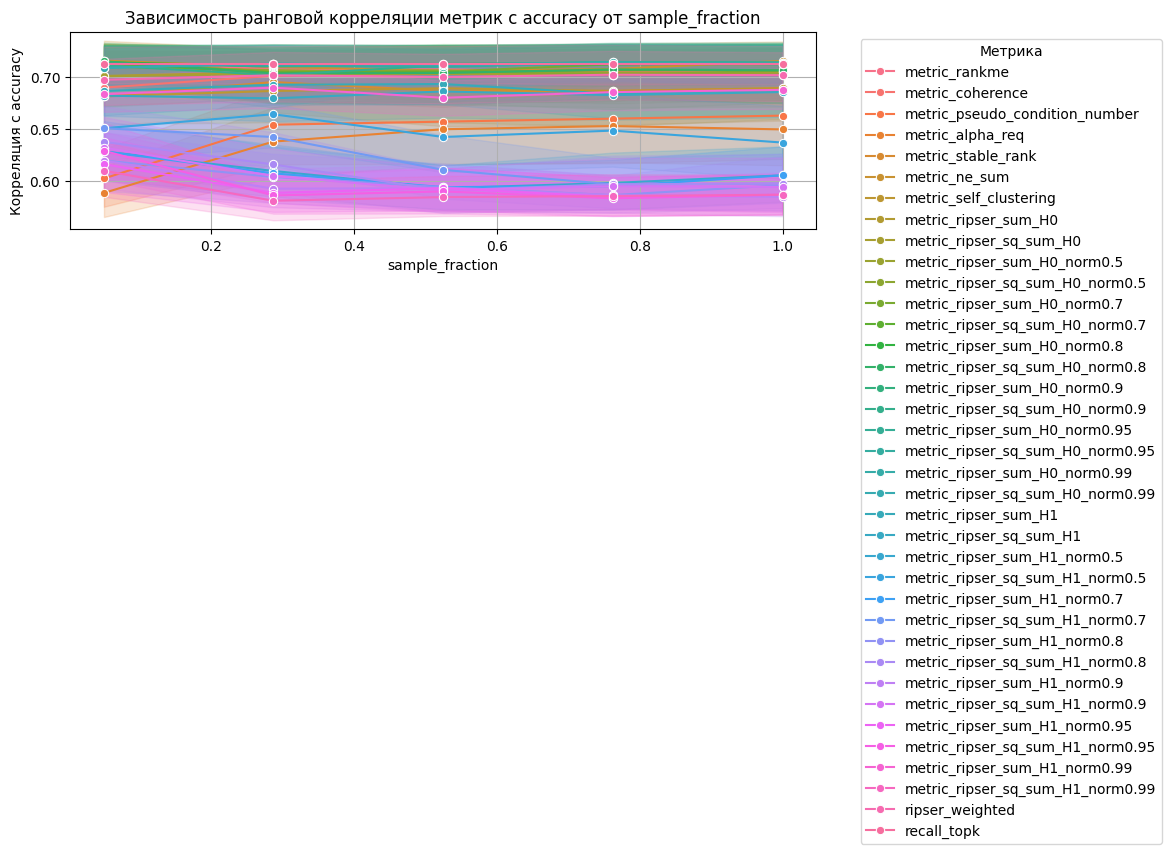

In [29]:
corr_df = pd.DataFrame(corr_records)

plt.figure(figsize=(12, 6))
sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
plt.xlabel("sample_fraction")
plt.ylabel("Корреляция с accuracy")
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
plt.tight_layout()
plt.show()

In [30]:
corr_df = pd.DataFrame(corr_records)
mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ripser_sum_H0_norm0.9': 0.7133673684210527,
 'metric_ripser_sum_H0_norm0.8': 0.7128526315789474,
 'metric_ripser_sum_H0_norm0.95': 0.7127463157894737,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7126463157894738,
 'recall_topk': 0.7126368421052632,
 'metric_ripser_sum_H0_norm0.99': 0.7124157894736842,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7120452631578947,
 'metric_ne_sum': 0.711321052631579,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7108463157894737,
 'metric_ripser_sum_H0_norm0.7': 0.7098378947368421,
 'metric_rankme': 0.7082231578947368,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7076231578947368,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7073957894736842,
 'metric_ripser_sq_sum_H0_norm0.5': 0.7071968421052631,
 'metric_ripser_sum_H0_norm0.5': 0.7057905263157894,
 'metric_coherence': 0.7044473684210526,
 'metric_ripser_sum_H0': 0.704238947368421,
 'metric_ripser_sq_sum_H0': 0.703021052631579,
 'ripser_weighted': 0.7009273684210526,
 'metric_ripser_sum_H1': 0.6890294736842106,
 'metric_stabl

In [31]:
mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.7158947368421053,
 'metric_ripser_sum_H0_norm0.95': 0.7143473684210526,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7143473684210526,
 'metric_ripser_sq_sum_H0_norm0.9': 0.7140947368421052,
 'metric_ripser_sum_H0_norm0.8': 0.7138789473684211,
 'metric_ripser_sum_H0_norm0.9': 0.7138789473684211,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7130526315789474,
 'metric_ripser_sum_H0_norm0.7': 0.7127105263157895,
 'recall_topk': 0.7126368421052632,
 'metric_ripser_sum_H0_norm0.99': 0.7125789473684211,
 'metric_coherence': 0.7072157894736842,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7068631578947369,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7068421052631578,
 'metric_ripser_sq_sum_H0_norm0.5': 0.7064526315789473,
 'metric_rankme': 0.7050263157894737,
 'metric_ripser_sq_sum_H0': 0.7047315789473685,
 'metric_ripser_sum_H0': 0.7047315789473685,
 'metric_ripser_sum_H0_norm0.5': 0.7026105263157895,
 'ripser_weighted': 0.7021421052631579,
 'metric_stable_rank': 0.6894526315789474,
 'metric_self

In [32]:
mean_corr = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["auc"].mean().sort_values(ascending=False)
mean_corr.to_dict()

{'metric_ne_sum': 0.7131,
 'metric_ripser_sum_H0_norm0.8': 0.7128342105263158,
 'metric_ripser_sum_H0_norm0.9': 0.7128315789473685,
 'recall_topk': 0.7126368421052632,
 'metric_ripser_sq_sum_H0_norm0.95': 0.7123421052631579,
 'metric_ripser_sum_H0_norm0.95': 0.7119342105263158,
 'metric_rankme': 0.7116289473684211,
 'metric_ripser_sum_H0_norm0.99': 0.7112105263157895,
 'metric_ripser_sq_sum_H0_norm0.99': 0.7112105263157895,
 'metric_ripser_sq_sum_H0_norm0.5': 0.7102421052631579,
 'metric_ripser_sq_sum_H0_norm0.8': 0.7096552631578947,
 'metric_ripser_sum_H0_norm0.7': 0.7091736842105263,
 'metric_ripser_sq_sum_H0_norm0.7': 0.7091078947368421,
 'metric_ripser_sum_H0_norm0.5': 0.7087447368421053,
 'metric_ripser_sq_sum_H0_norm0.9': 0.70685,
 'metric_ripser_sum_H0': 0.7032736842105263,
 'metric_ripser_sq_sum_H0': 0.7022342105263157,
 'metric_coherence': 0.7009052631578947,
 'ripser_weighted': 0.6998184210526316,
 'metric_ripser_sum_H1': 0.689828947368421,
 'metric_stable_rank': 0.6885394736

In [47]:
from collections import defaultdict
comb_w = defaultdict(dict)
comb_prod = defaultdict(dict)

for metric in metric_columns:
    for i in range(mean_corr.shape[0]):
        if metric in mean_corr.index.values[i]:
            if 'prod' in mean_corr.index.values[i]:
                comb_prod[metric][mean_corr.index.values[i]] = mean_corr.values[i]
            elif 'weighted' in mean_corr.index.values[i]:
                comb_w[metric][mean_corr.index.values[i]] = mean_corr.values[i]



In [48]:
for metric in metric_columns:
    comb_prod[metric] = pd.Series(comb_prod[metric])
    print (metric, comb_prod[metric].mean())
    comb_w[metric] = pd.Series(comb_w[metric])
    print (metric, comb_w[metric].mean())

metric_rankme 0.666
metric_rankme 0.6762619047619047
metric_coherence 0.6330095238095238
metric_coherence 0.6955904761904761
metric_pseudo_condition_number 0.5502380952380953
metric_pseudo_condition_number 0.6199714285714284
metric_alpha_req 0.5720761904761905
metric_alpha_req 0.5971428571428571
metric_stable_rank 0.6475095238095238
metric_stable_rank 0.6088619047619046
metric_ne_sum 0.6910619047619048
metric_ne_sum 0.6973476190476191
metric_self_clustering 0.6342523809523809
metric_self_clustering 0.6544333333333332
metric_ripser 0.6135877192982457
metric_ripser 0.6264578947368421
metric_ripser_sum 0.6135877192982457
metric_ripser_sum 0.6264578947368421
metric_ripser_sum_H0 0.628747619047619
metric_ripser_sum_H0 0.6540333333333331
metric_ripser_sum_H1 0.5756428571428571
metric_ripser_sum_H1 0.593642857142857
ripser_weighted 0.5834142857142857
ripser_weighted 0.5926636363636363


# Corr of best hyperparam by metric

In [34]:
from collections import defaultdict
params_cols=["batch_size","learning_rate",
    "split_count",
    "cnt_min",
    "cnt_max",
    "embedding_dim",
    "category_embedding_dim",
    "hidden_size"]

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique()> 1:
                    corr = check_data[metric].corr(
                        check_data['roc_auc'], method='spearman')
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "corr": sign * corr
                    })

/tmp/ipykernel_3412665/1720882012.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_3412665/1720882012.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub[combined] = sub[curr_params].astype(str).sum(axis=1)
/tmp/ipykernel_3412665/1720882012.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentati

batch_size


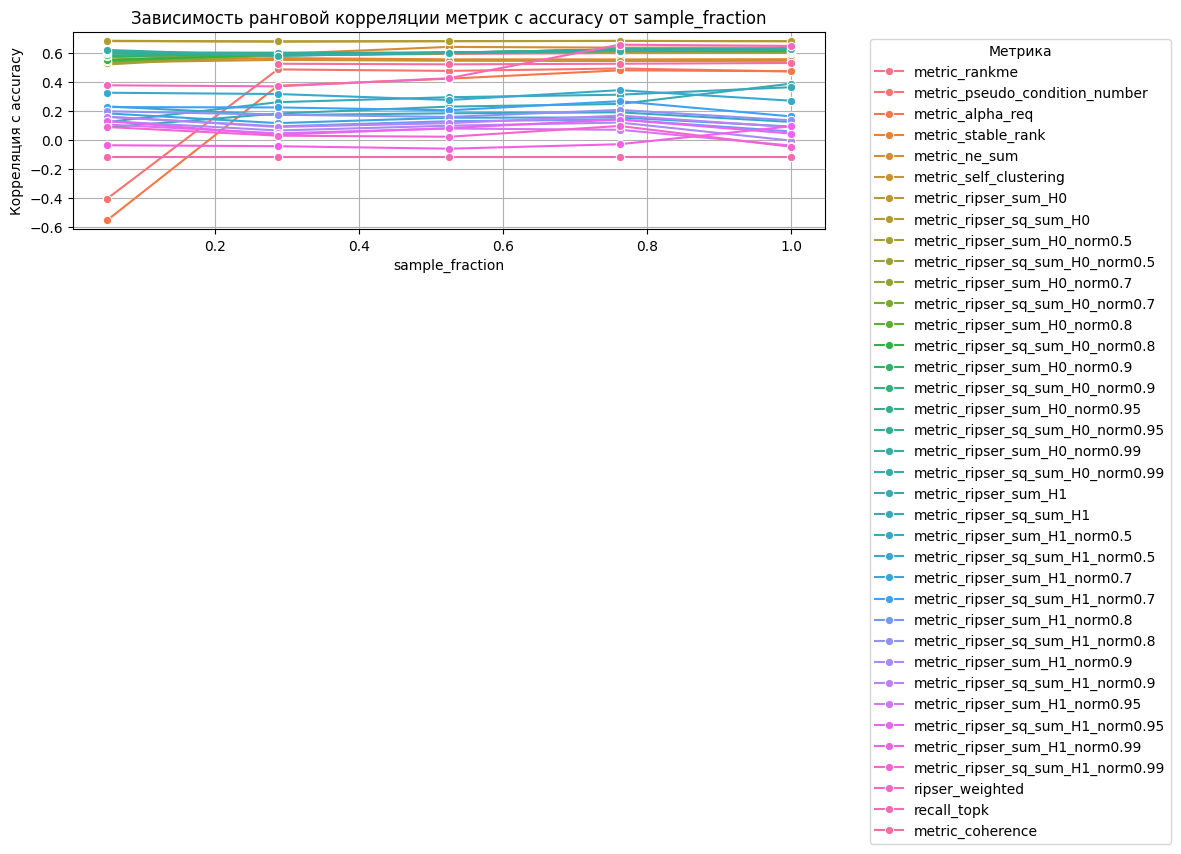

learning_rate


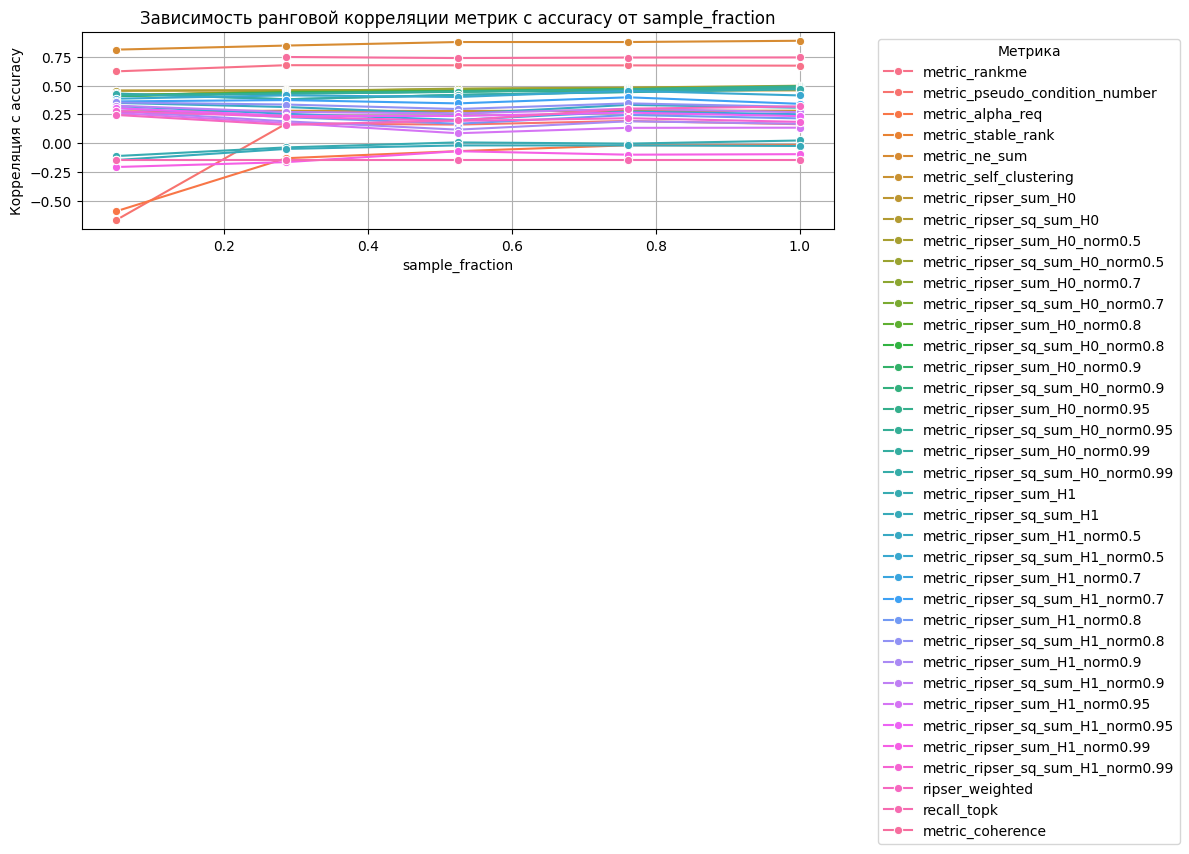

split_count


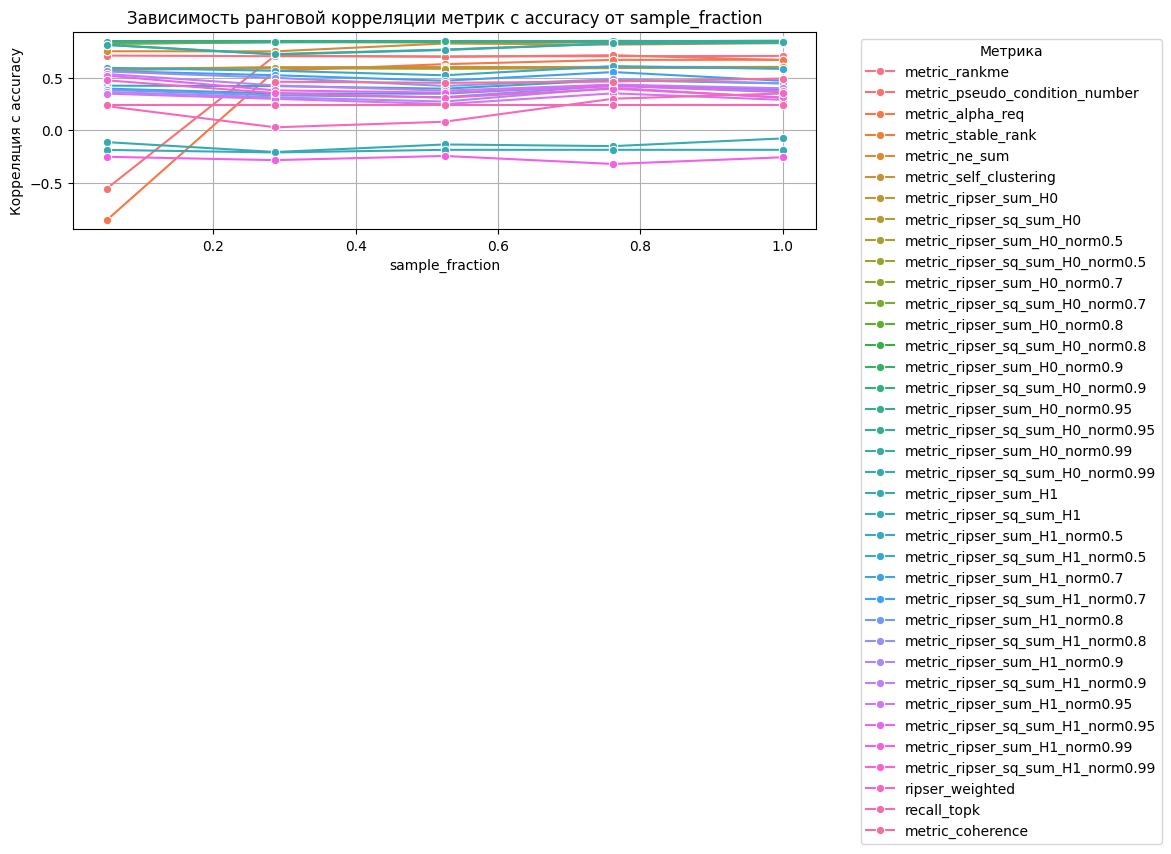

cnt_min


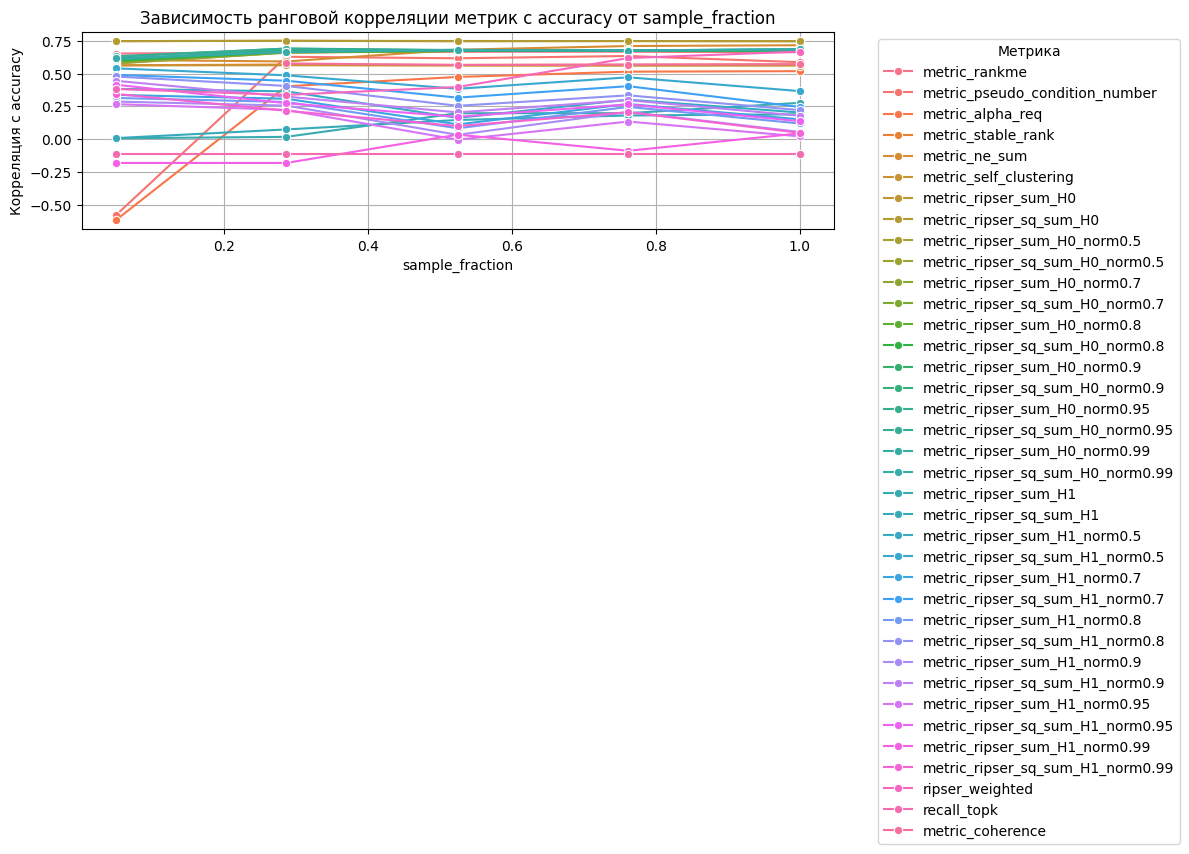

cnt_max


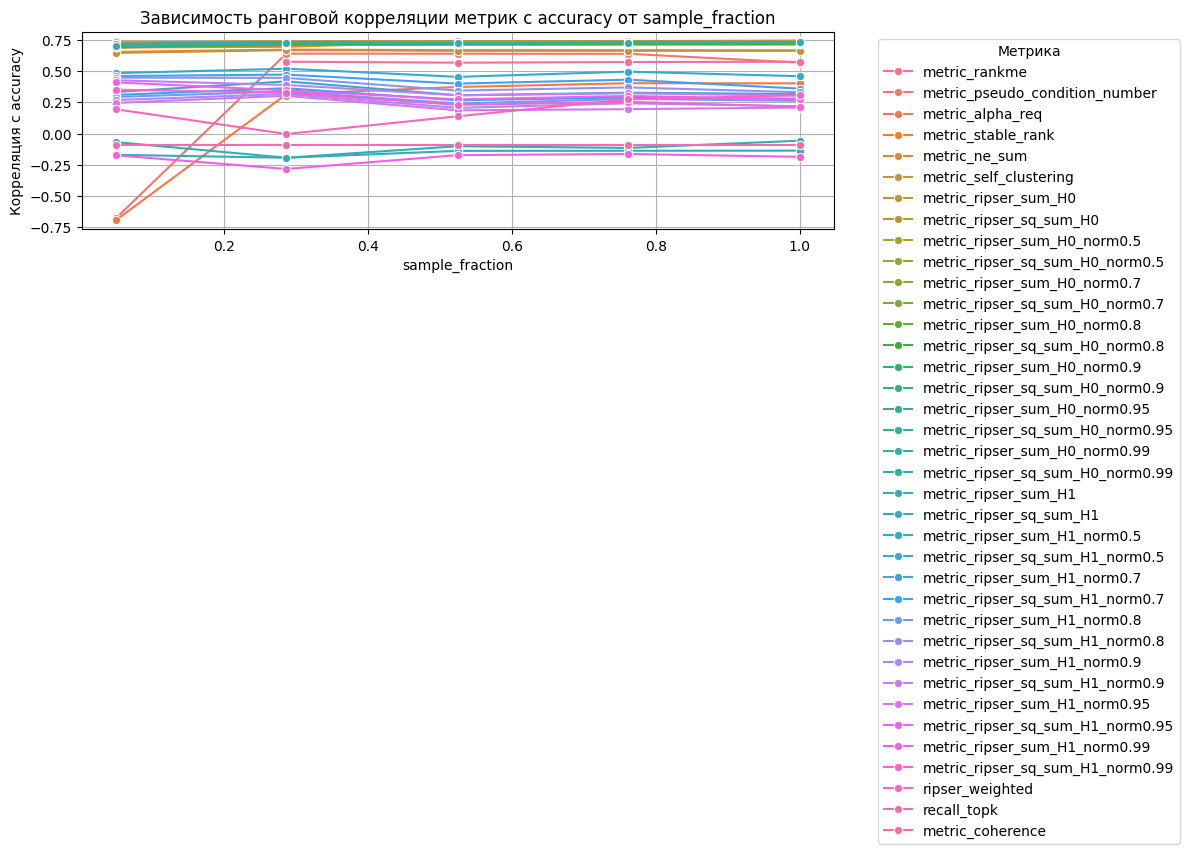

embedding_dim


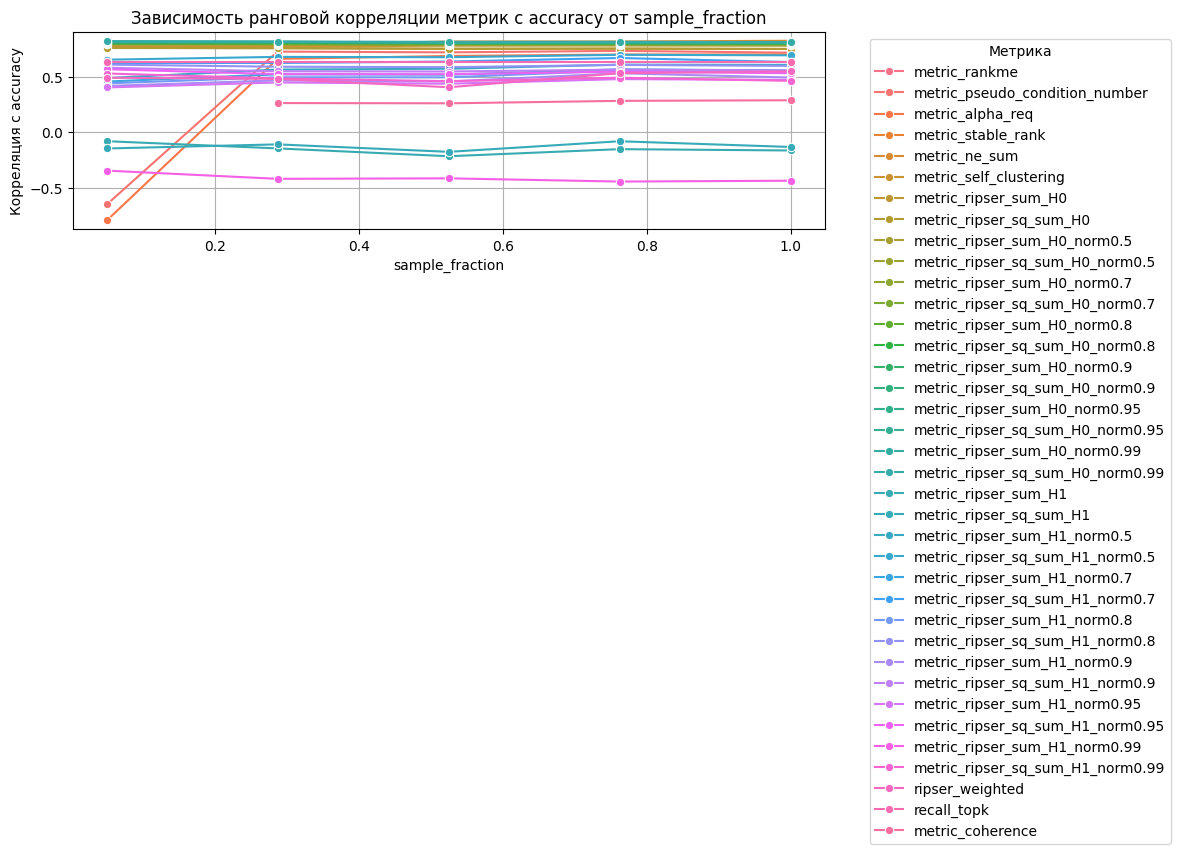

category_embedding_dim


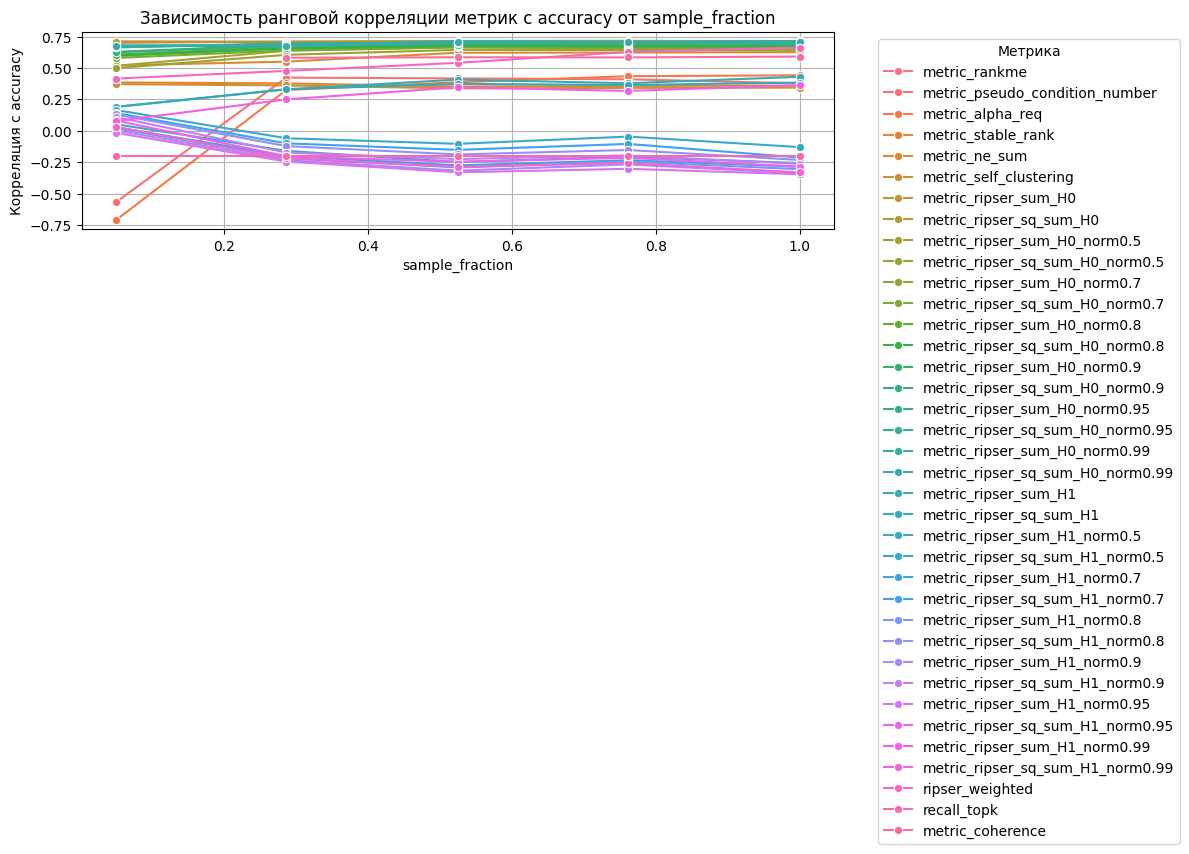

hidden_size


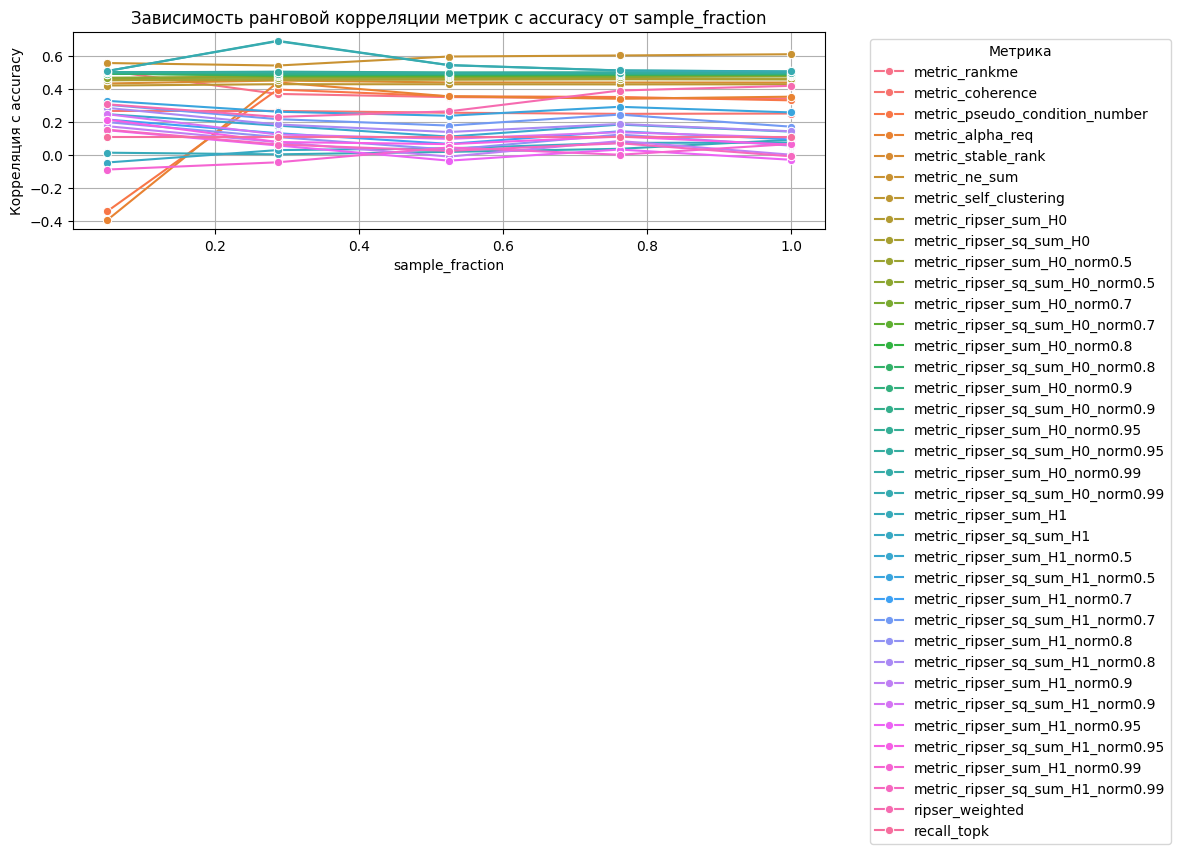

In [35]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="corr", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()

In [36]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["corr"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sq_sum_H0             0.682775
metric_ripser_sum_H0                0.681125
metric_ripser_sq_sum_H0_norm0.95    0.603899
metric_ripser_sq_sum_H0_norm0.99    0.601692
metric_ripser_sum_H0_norm0.95       0.600355
metric_ripser_sum_H0_norm0.99       0.597713
metric_ripser_sq_sum_H0_norm0.9     0.588726
metric_ripser_sum_H0_norm0.9        0.585739
metric_ne_sum                       0.582928
metric_ripser_sq_sum_H0_norm0.7     0.572117
metric_ripser_sq_sum_H0_norm0.8     0.569963
metric_ripser_sum_H0_norm0.7        0.569736
metric_ripser_sum_H0_norm0.8        0.569089
metric_rankme                       0.567482
metric_ripser_sq_sum_H0_norm0.5     0.558373
metric_stable_rank                  0.555089
metric_ripser_sum_H0_norm0.5        0.554117
metric_self_clustering              0.544144
metric_coherence                    0.526158
ripser_weighted                     0.373404
metric_ripser_sq_sum_H1_norm0.5     0.321221
metric_ripser_sq_sum_H1_norm0.7     0

# Score of best hyperparams by metric

In [ ]:
from collections import defaultdict
params_cols=["batch_size","learning_rate",
    "split_count",
    "cnt_min",
    "cnt_max",
    "embedding_dim",
    "category_embedding_dim",
    "hidden_size"]

corr_records = defaultdict(list)
runs = df_all['checkpoint'].values
for i in range(df_all.shape[0]):
    runs[i] = runs[i][:-10]

df_all['runs'] = runs

for frac in sorted(df_all['sample_fraction'].unique()):
    sub = df_all[df_all['sample_fraction'] == frac]
    #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
    for param in params_cols:
        curr_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_params)
        sub[combined] = sub[curr_params].astype(str).sum(axis=1)
        for metric in metric_columns:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                sub['roc_auc'], method='spearman'))
            for check, check_data in sub.groupby(combined):   
                if check_data[param].nunique() <= 1:
                    continue
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                    
                    pick = check_data['roc_auc'].values[
                        np.argmax(sign * check_data[metric].values)]
                    corr_records[param].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "auc": pick
                    })

batch_size


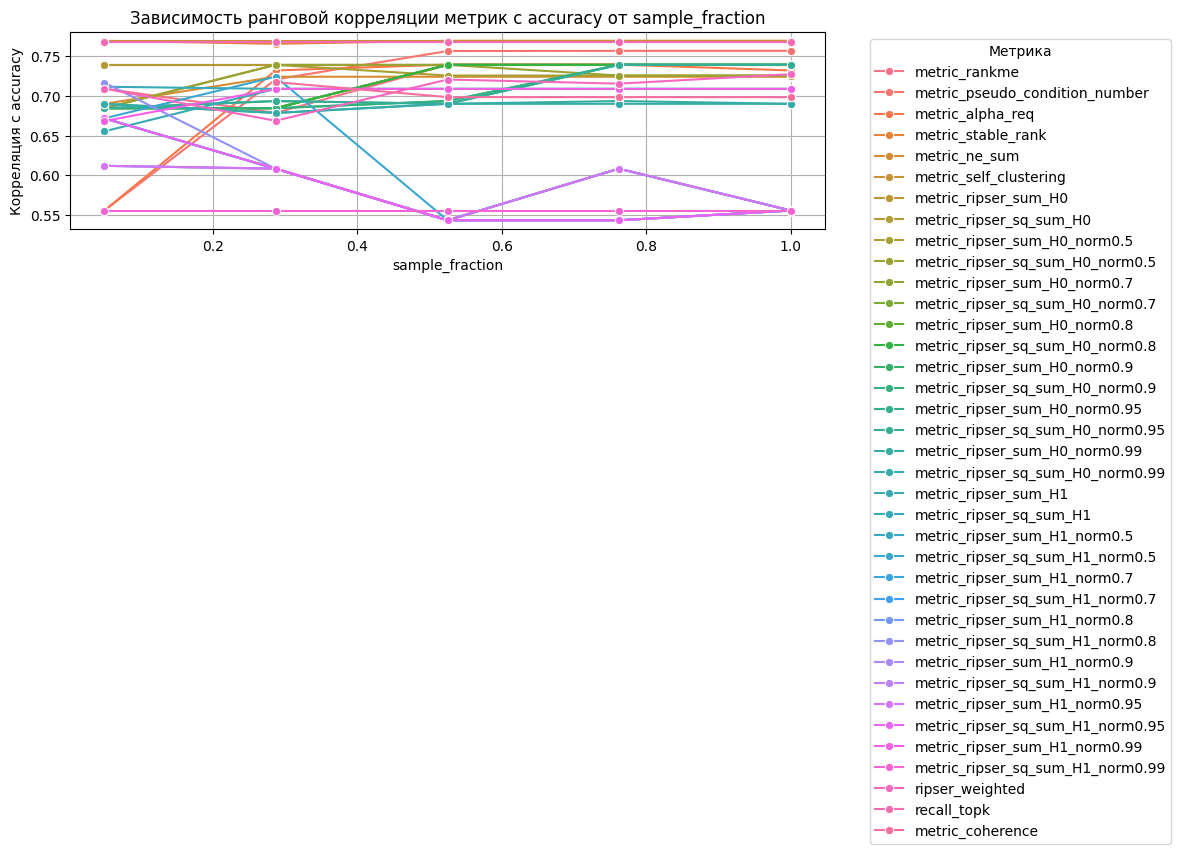

learning_rate


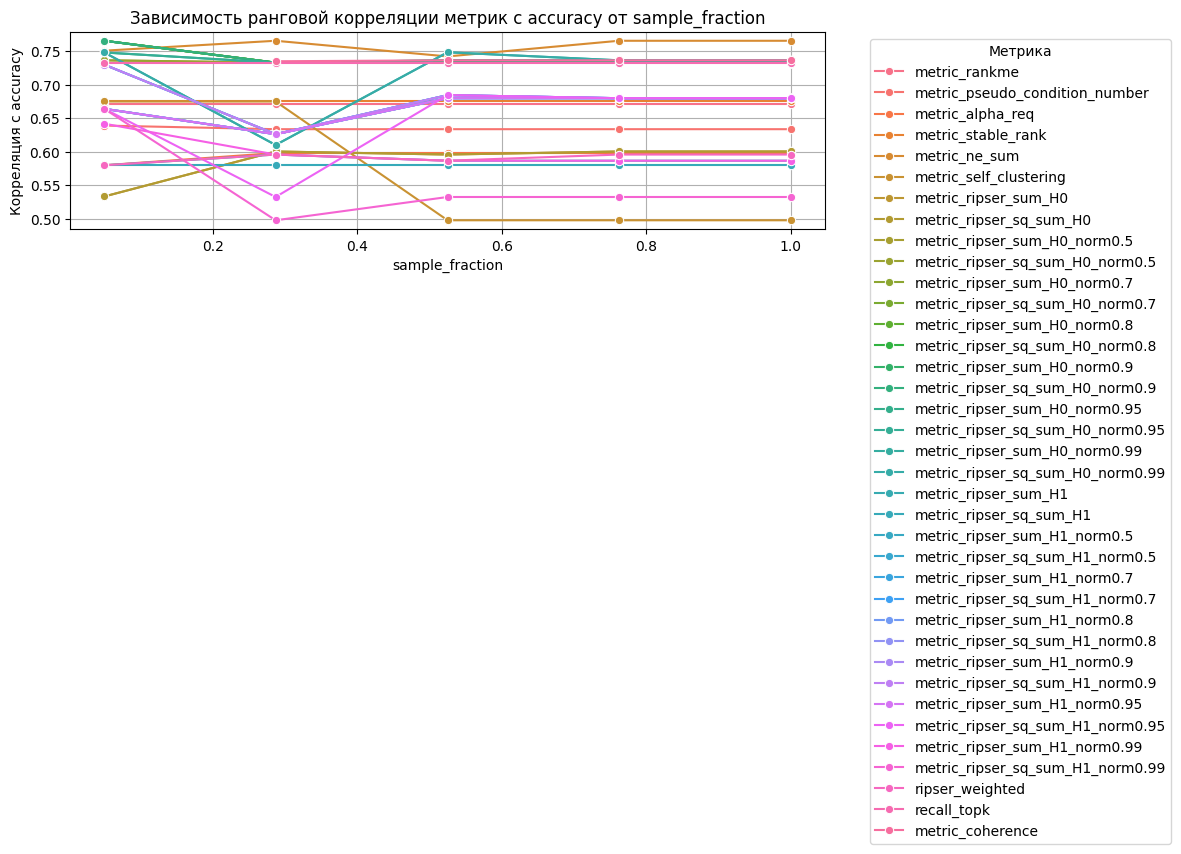

split_count


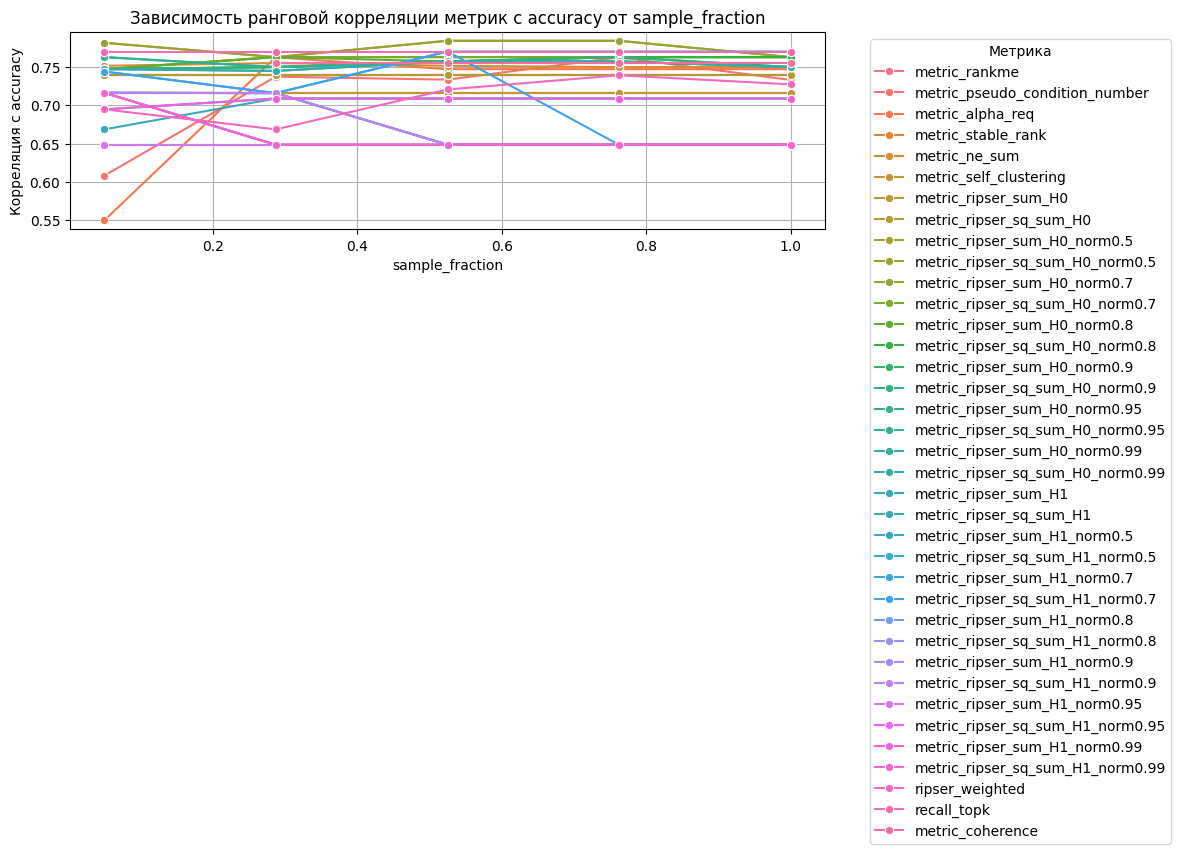

cnt_min


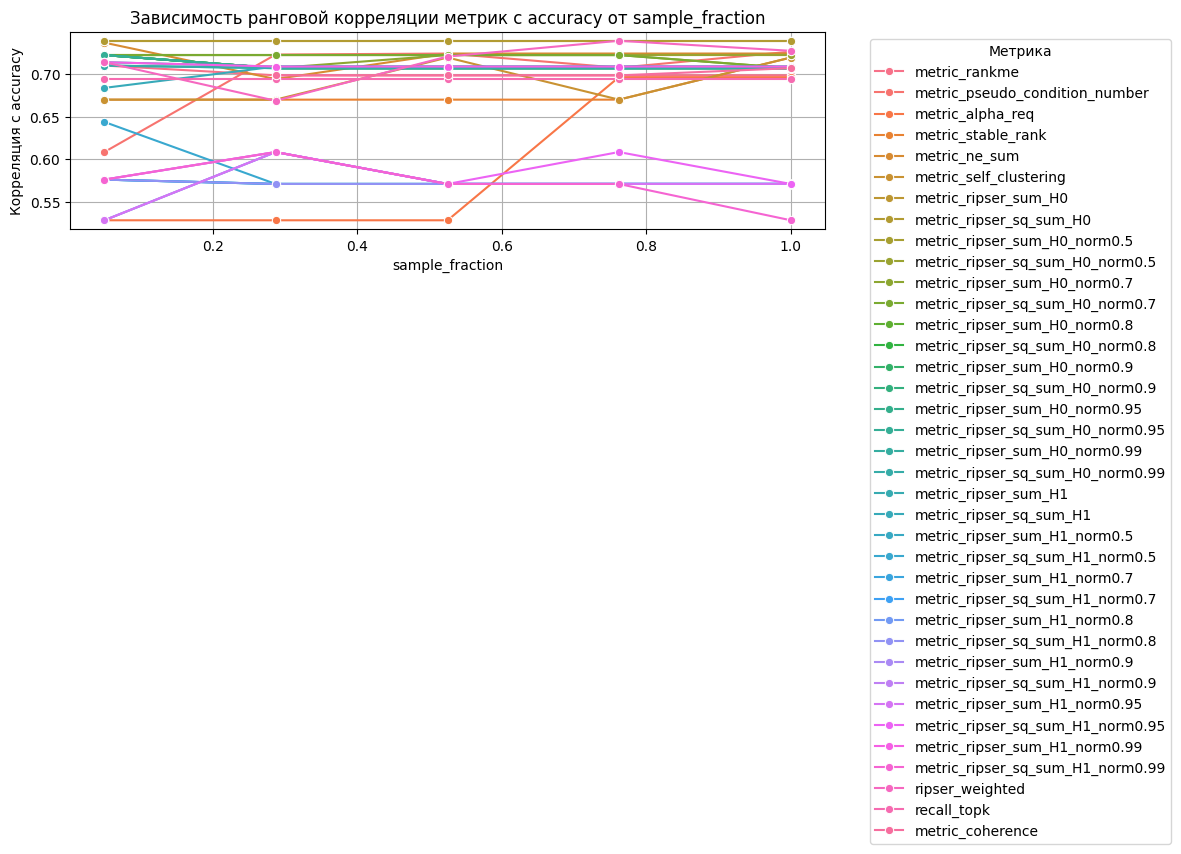

cnt_max


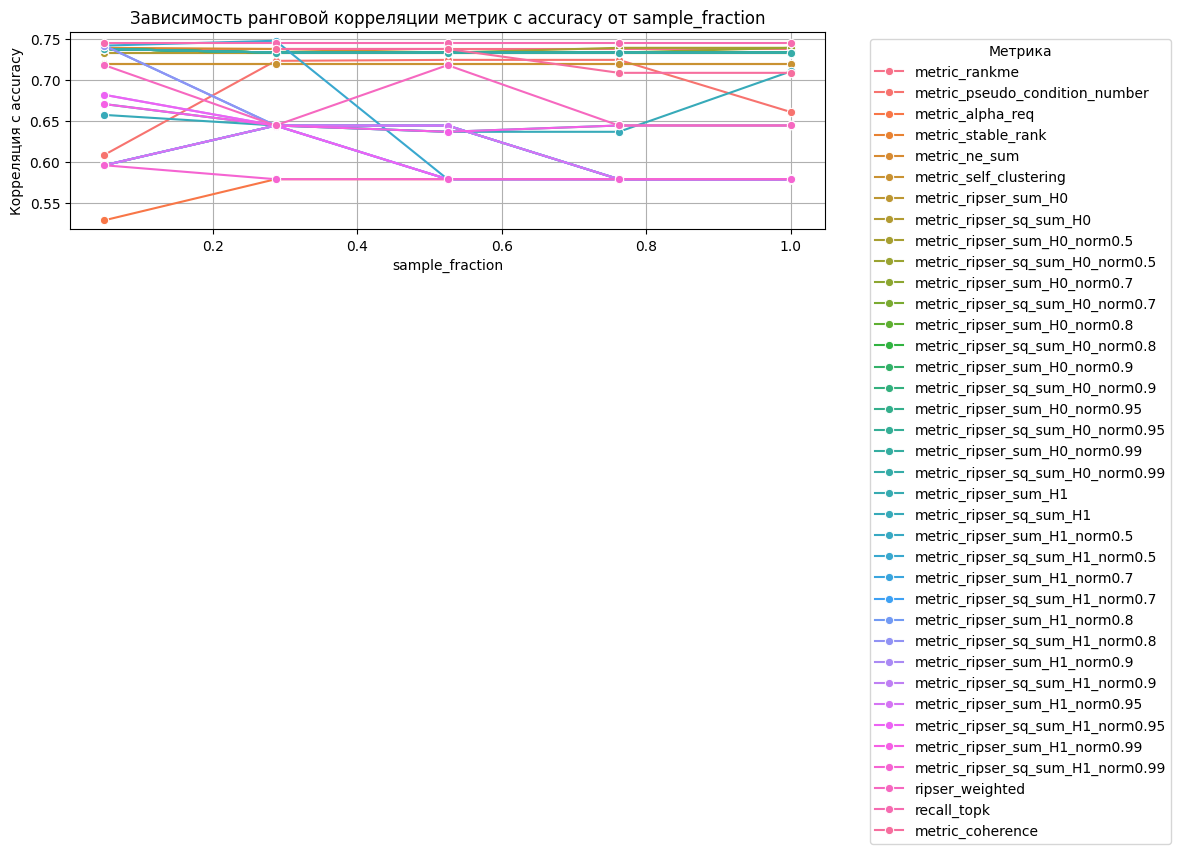

embedding_dim


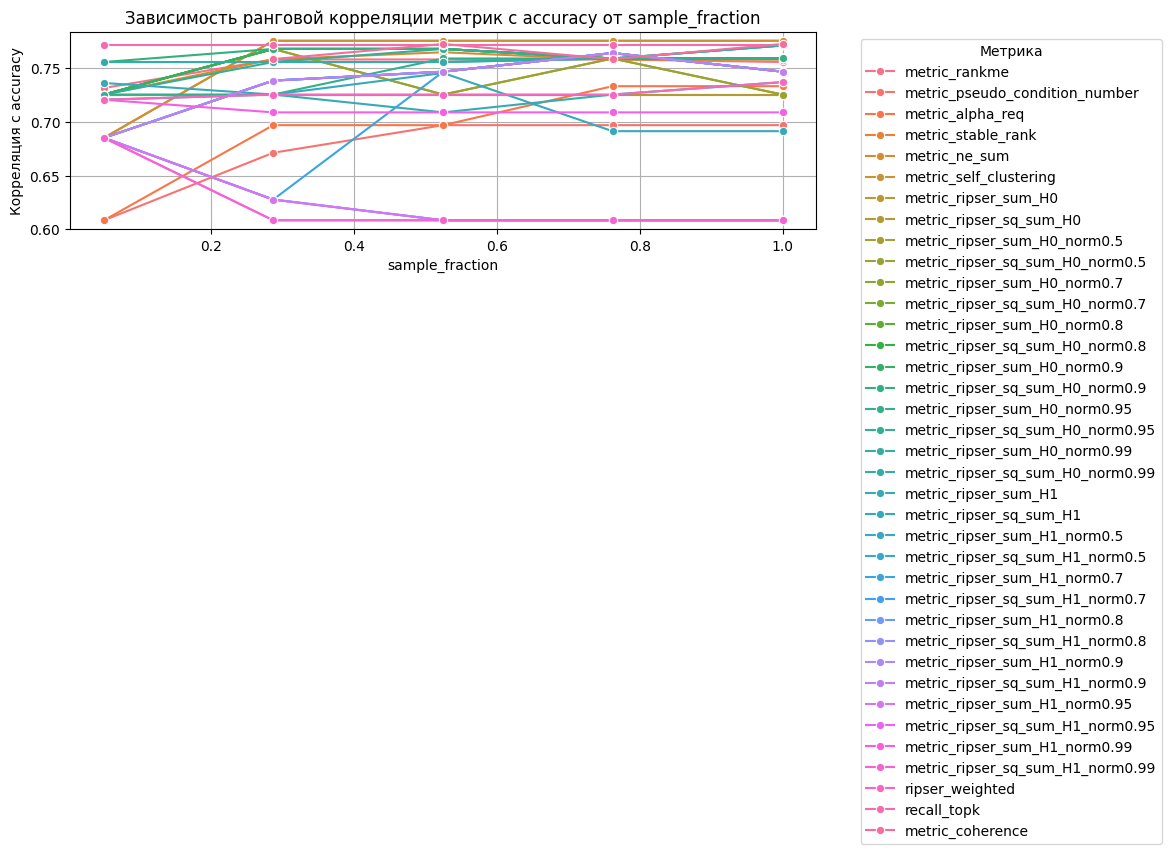

category_embedding_dim


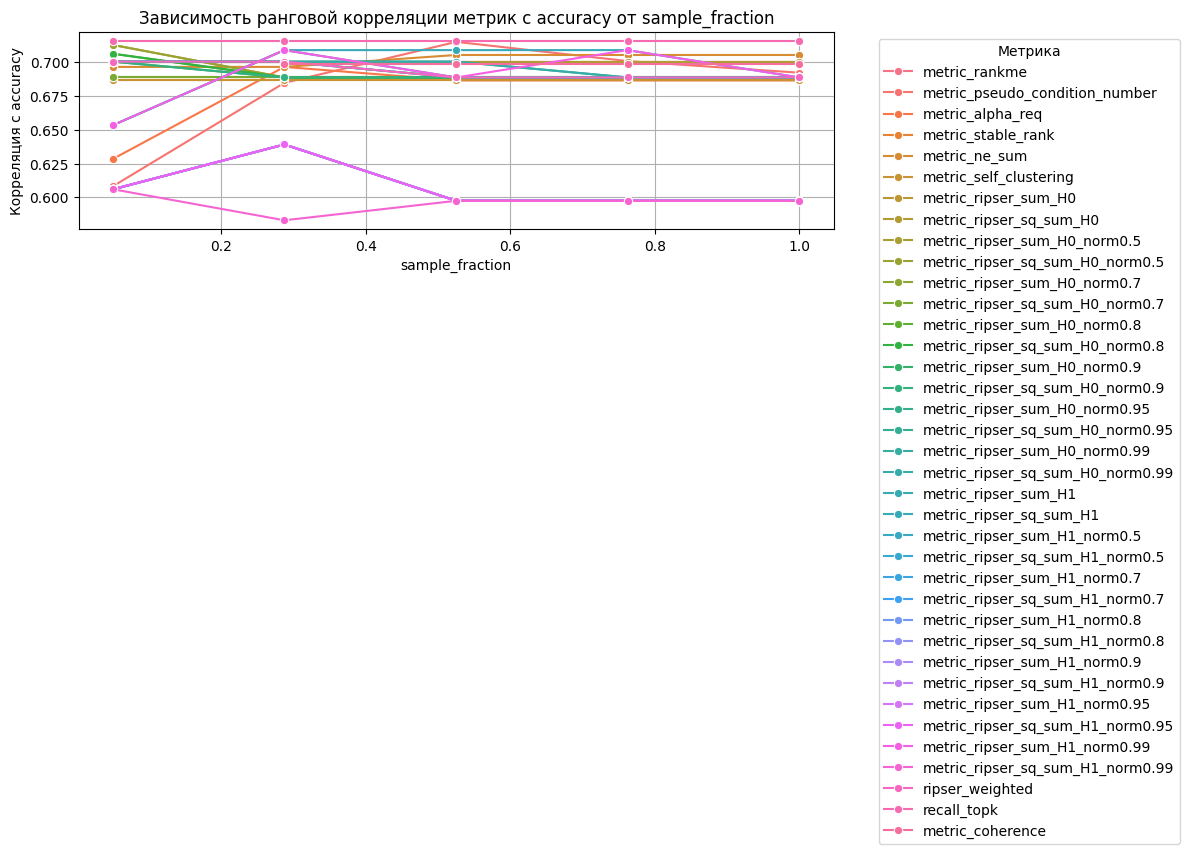

hidden_size


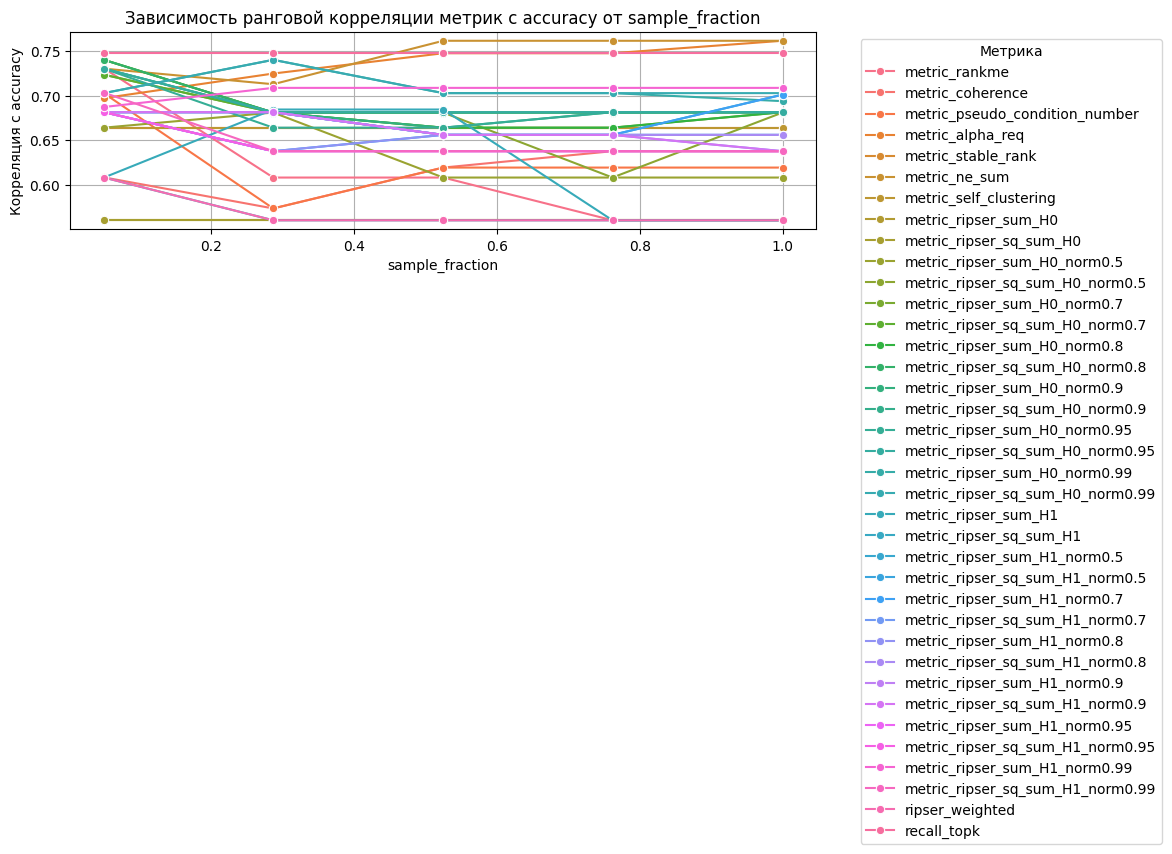

In [38]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    print(param)
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=corr_df, x="sample_fraction", y="auc", hue="metric", marker="o")
    plt.title("Зависимость ранговой корреляции метрик с accuracy от sample_fraction")
    plt.xlabel("sample_fraction")
    plt.ylabel("Корреляция с accuracy")
    plt.grid(True)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Метрика")
    plt.tight_layout()
    plt.show()
    

In [39]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] < 0.5].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_self_clustering              0.76940
recall_topk                         0.76810
metric_stable_rank                  0.76750
metric_ripser_sq_sum_H0             0.73910
metric_ripser_sum_H0                0.73910
metric_coherence                    0.71740
metric_ripser_sum_H0_norm0.5        0.71180
metric_ripser_sq_sum_H0_norm0.5     0.71180
metric_ripser_sq_sum_H1             0.71015
metric_ne_sum                       0.70705
metric_ripser_sq_sum_H1_norm0.5     0.69790
metric_rankme                       0.69385
metric_ripser_sum_H0_norm0.95       0.68900
metric_ripser_sq_sum_H0_norm0.95    0.68900
ripser_weighted                     0.68890
metric_ripser_sum_H1_norm0.99       0.68855
metric_ripser_sum_H0_norm0.7        0.68450
metric_ripser_sum_H0_norm0.9        0.68450
metric_ripser_sq_sum_H0_norm0.9     0.68450
metric_ripser_sq_sum_H0_norm0.7     0.68450
metric_ripser_sq_sum_H0_norm0.8     0.68450
metric_ripser_sum_H0_norm0.8        0.68450
metric_ripser_

In [40]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_stable_rank                  0.7694
metric_self_clustering              0.7694
recall_topk                         0.7681
metric_pseudo_condition_number      0.7567
metric_rankme                       0.7391
metric_ripser_sum_H0_norm0.7        0.7391
metric_ripser_sum_H0_norm0.95       0.7391
metric_ripser_sum_H0_norm0.8        0.7391
metric_ripser_sq_sum_H0             0.7391
metric_ripser_sq_sum_H0_norm0.95    0.7391
metric_ripser_sq_sum_H0_norm0.7     0.7391
metric_ripser_sq_sum_H0_norm0.8     0.7391
metric_ripser_sq_sum_H0_norm0.9     0.7391
metric_ripser_sum_H0                0.7391
metric_ripser_sum_H0_norm0.9        0.7391
metric_alpha_req                    0.7320
ripser_weighted                     0.7273
metric_ripser_sum_H0_norm0.5        0.7256
metric_ripser_sq_sum_H0_norm0.5     0.7256
metric_ne_sum                       0.7241
metric_ripser_sum_H1_norm0.99       0.7088
metric_ripser_sq_sum_H1             0.7088
metric_ripser_sum_H1                

In [41]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_self_clustering              0.76940
metric_stable_rank                  0.76864
recall_topk                         0.76810
metric_ripser_sq_sum_H0             0.73910
metric_ripser_sum_H0                0.73910
metric_ripser_sq_sum_H0_norm0.5     0.72278
metric_rankme                       0.72100
metric_ripser_sum_H0_norm0.5        0.72008
metric_ne_sum                       0.71728
metric_ripser_sum_H0_norm0.7        0.71726
metric_ripser_sq_sum_H0_norm0.8     0.71726
metric_ripser_sum_H0_norm0.8        0.71726
metric_ripser_sq_sum_H0_norm0.7     0.71726
metric_ripser_sq_sum_H1             0.70934
metric_ripser_sum_H0_norm0.95       0.70924
metric_pseudo_condition_number      0.70924
metric_ripser_sq_sum_H0_norm0.95    0.70924
ripser_weighted                     0.70822
metric_ripser_sq_sum_H0_norm0.9     0.70814
metric_ripser_sum_H0_norm0.9        0.70814
metric_coherence                    0.70315
metric_ripser_sum_H1_norm0.99       0.70070
metric_alpha_r

In [74]:
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    mean_corr = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["auc"].mean().sort_values(ascending=False)
    print(param)
    print(mean_corr)

batch_size
metric
metric_ripser_sum_H0              0.751540
ripser_weighted                   0.744400
metric_ripser_sum                 0.740300
metric_ripser_sum_H1              0.729160
metric_alpha_req                  0.722520
metric_pseudo_condition_number    0.722320
metric_stable_rank                0.719900
metric_self_clustering            0.719900
recall_topk                       0.719900
metric_coherence                  0.711575
metric_rankme                     0.709220
metric_ne_sum                     0.705820
Name: auc, dtype: float64
learning_rate
metric
metric_ne_sum                     0.73350
recall_topk                       0.72450
metric_coherence                  0.70770
metric_rankme                     0.70210
ripser_weighted                   0.65940
metric_ripser_sum_H1              0.65940
metric_alpha_req                  0.63348
metric_ripser_sum_H0              0.58778
metric_ripser_sum                 0.58778
metric_pseudo_condition_number    0.53640

# Standard deviation of score of best param selection

In [43]:
std_corr = {}
for param in params_cols:
    corr_df = pd.DataFrame(corr_records[param])
    std_corr[param] = corr_df.groupby("metric")["auc"].std().sort_values()

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


batch_size


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


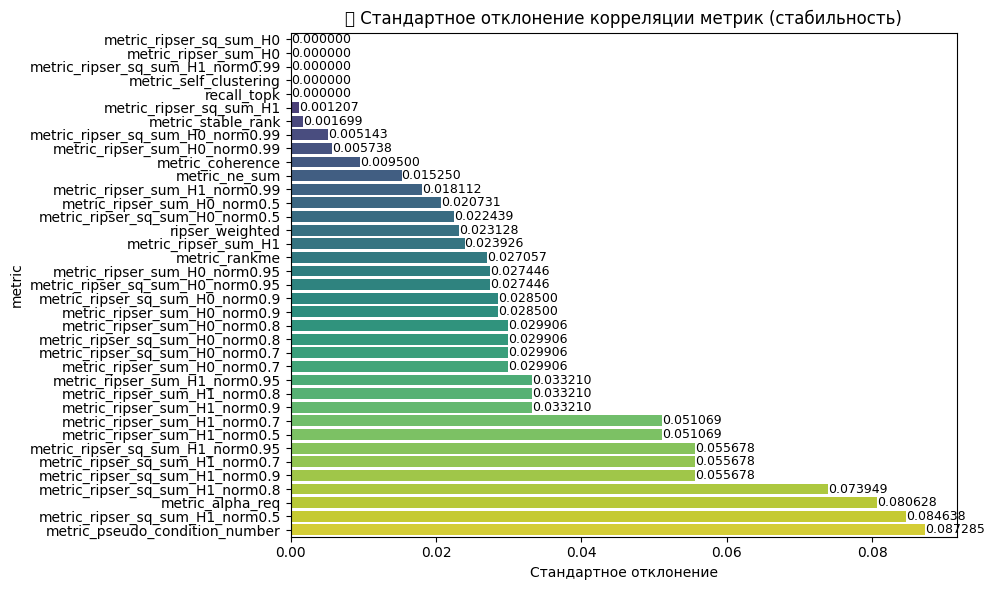

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


learning_rate


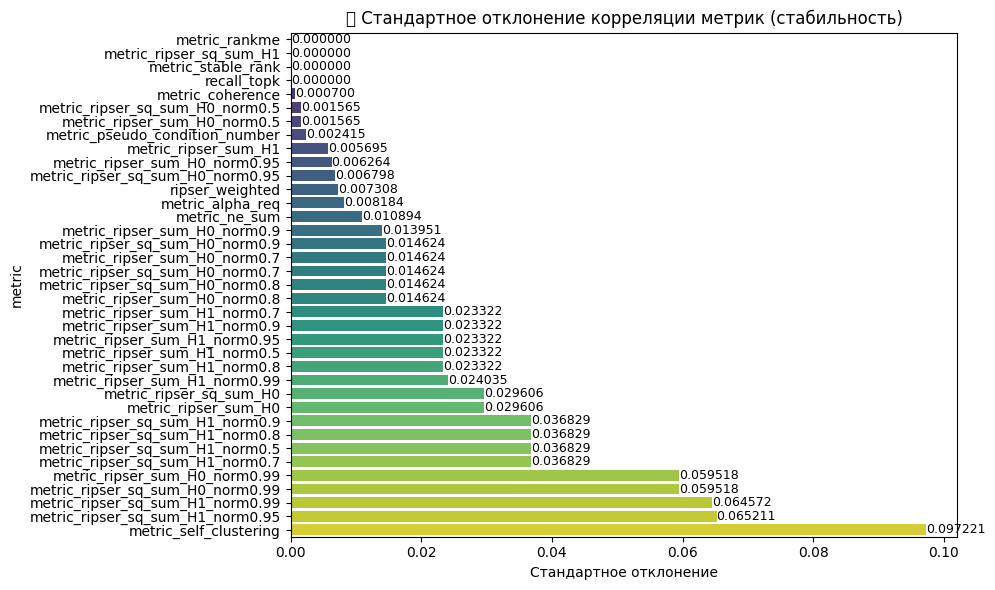

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")


split_count


/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


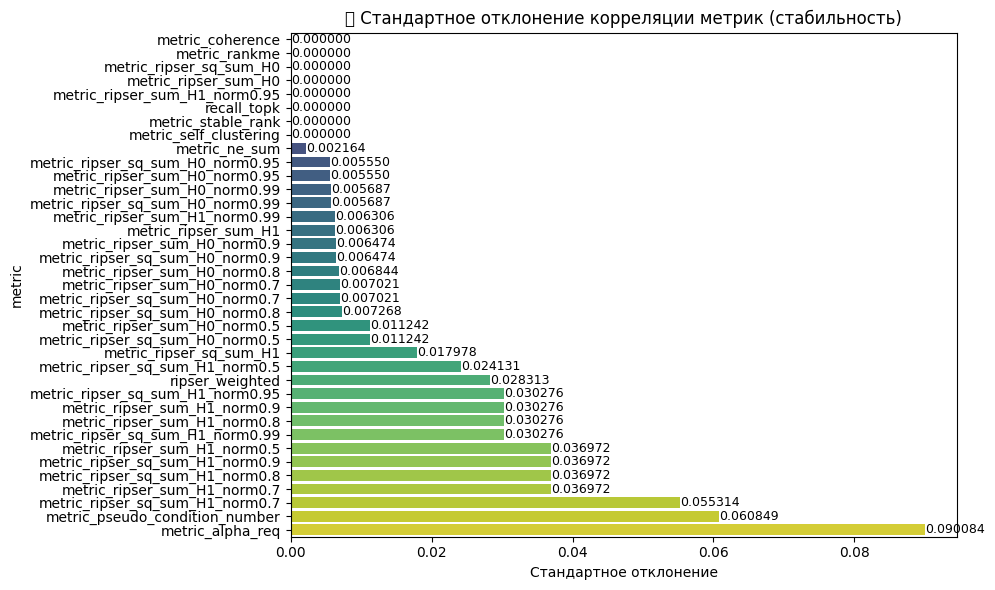

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_min


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


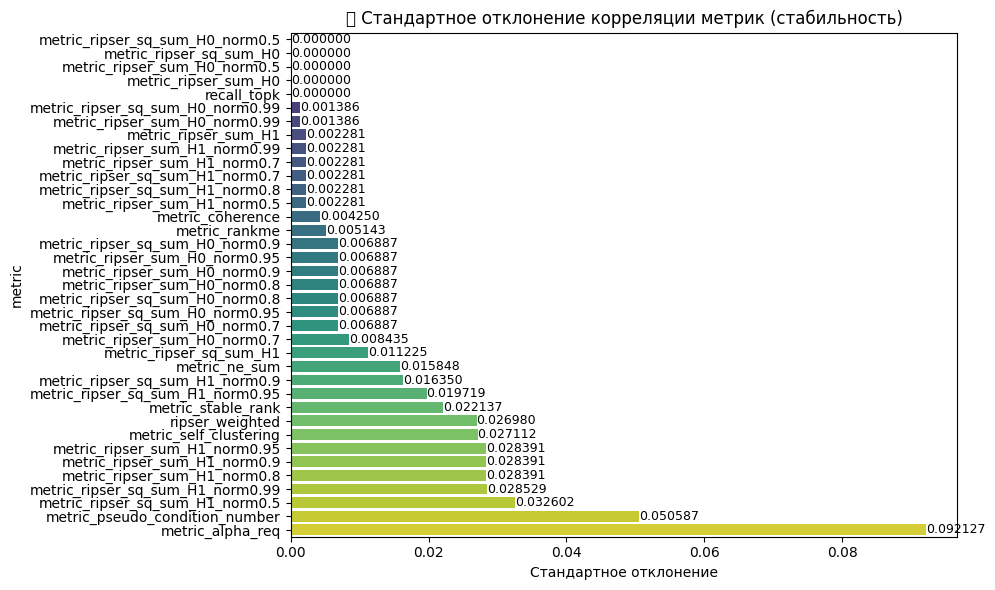

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_max


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


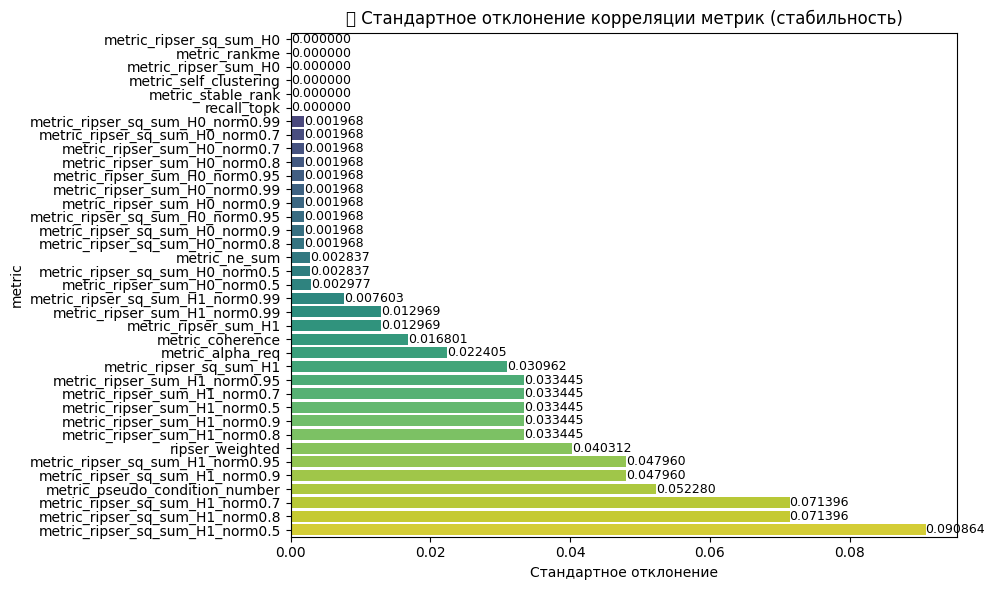

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


embedding_dim


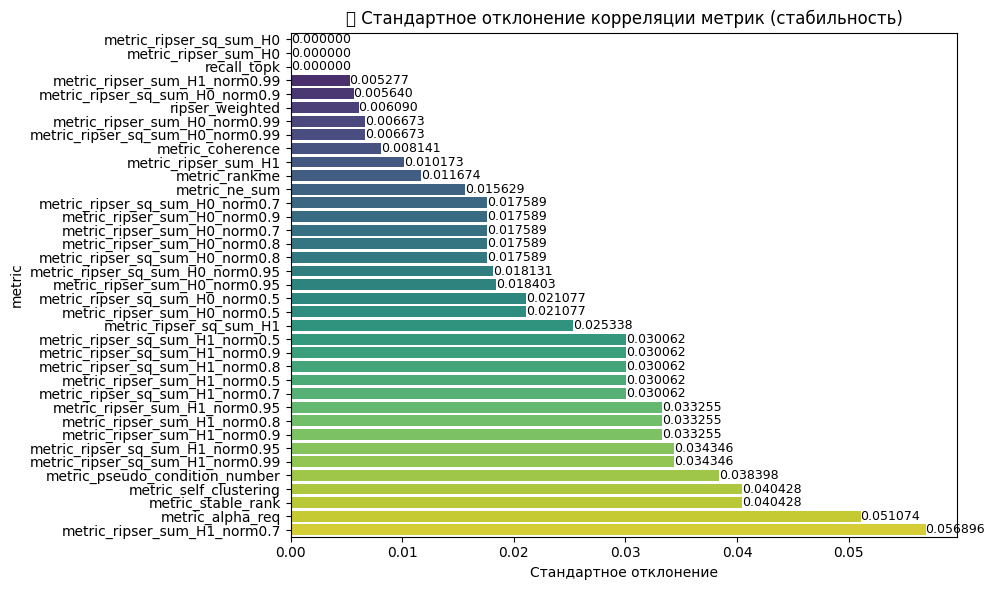

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


category_embedding_dim


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


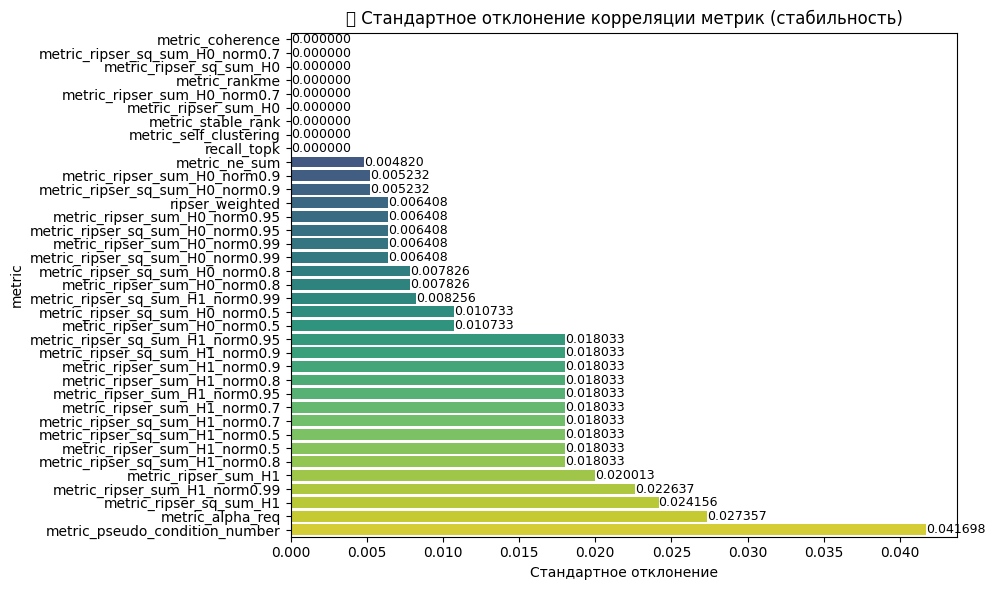

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


hidden_size


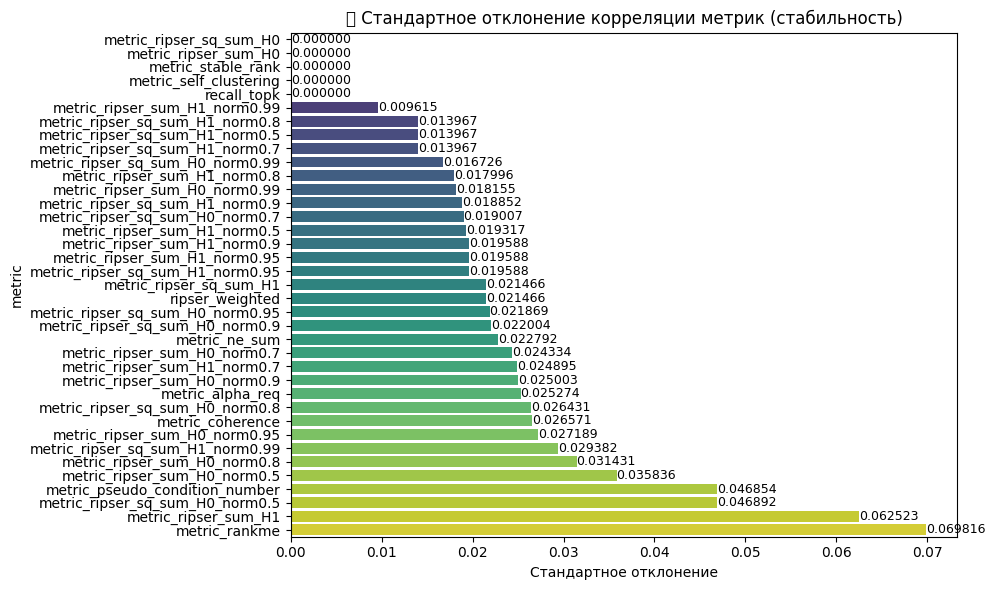

In [45]:
for param in params_cols:
    sorted_std = std_corr[param].sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
    
    for i, v in enumerate(sorted_std.values):
        plt.text(v, i, f"{v:.6f}", color='black', ha='left', va='center', fontsize=9)
    print(param)
    plt.title("📉 Стандартное отклонение корреляции метрик (стабильность)")
    plt.xlabel("Стандартное отклонение")
    plt.tight_layout()
    plt.show()